### Import Library

In [1]:
# Core
import re
from functools import lru_cache

# Data
import numpy as np
import pandas as pd

# HTTP (judul video via oEmbed)
import requests

# Viz
import matplotlib.pyplot as plt

# Notebook display
from IPython.display import display, HTML

# NLP quick stats
from sklearn.feature_extraction.text import CountVectorizer

Disini saya import librarynya terlebih dahulu untuk melakukan EDA

1. re

   Dipakai untuk regex, misalnya menghitung jumlah kata (\w+), membersihkan URL, menghapus karakter tertentu, dan normalisasi spasi pada teks komentar.

2. lru_cache (functools)


   Untuk cache hasil fungsi, terutama saat mengambil judul video via oEmbed. Jika video_id yang sama dipanggil ulang, tidak perlu request lagi sehingga lebih cepat dan hemat request.

3. numpy as np


   Membantu operasi numerik ringan dan statistik sederhana (sering dipakai bareng pandas).

4. pandas as pd


   Library utama untuk data tabular: baca CSV, cek missing values, value_counts, groupby per video, sorting, dan membuat ringkasan EDA.

5. requests


   Untuk HTTP request ke endpoint YouTube oEmbed agar bisa mendapatkan judul video (video_title) tanpa perlu YouTube Data API.

6. matplotlib.pyplot as plt


Untuk visualisasi EDA standar seperti histogram panjang kata dan bar chart jumlah komentar per video.

7. display, HTML (IPython.display)


Agar output notebook lebih rapi, termasuk membuat tabel dan link judul video yang bisa diklik.

8. CountVectorizer (scikit-learn)

Untuk EDA teks cepat: menghitung frekuensi unigram/bigram (kata dan pasangan kata) sehingga terlihat kata-kata yang paling sering muncul di dataset.


## EDA

### Load data

In [2]:
# Path Dataset
DATA_PATH = "yt_comments_prioritized_4000.csv"

# Load Dataset
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

# Cek Dataset
print("Loaded:", DATA_PATH)

df.head()

Loaded: yt_comments_prioritized_4000.csv


,video_id,source_group,comment_id,parent_id,is_reply,author,text,like_count,published_at,updated_at,relevance_score
0,W-TbY_Pkjqk,priority,UgyZ5KfxtuFWlj4lcEJ4AaABAg,NaN,False,@sriutamiUtami-wq1tv,Guru tugasnya balik nguliti AI. Serta menjaga ...,0,2025-07-18T10:10:52Z,2025-07-25T12:52:06Z,9
1,W-TbY_Pkjqk,priority,Ugytb-_hDaG-r-xSh-R4AaABAg,NaN,False,@sriutamiUtami-wq1tv,"I ya Buk dari mulai mencari kata kunci, menari...",0,2025-07-18T09:41:56Z,2025-07-18T09:59:55Z,9
2,W-TbY_Pkjqk,priority,UgyxksFpJMrpOyeXRdN4AaABAg,NaN,False,@ivipitbull,selama AI dibatasi menyimpan data dan membuat ...,0,2025-03-18T11:59:40Z,2025-03-18T11:59:40Z,8
3,W-TbY_Pkjqk,priority,UgyOarg-XSs64tz0SUh4AaABAg,NaN,False,@rusidahrusidah5656,jk digunakan o/ Penjahat a/ jd kejahatan bsr ...,0,2024-11-05T06:50:29Z,2024-11-05T06:57:11Z,9
4,W-TbY_Pkjqk,priority,Ugw2FgWgq2vN3Aje9Uh4AaABAg,NaN,False,@paternuserwin,"AI lambat laun akan menjadi kebuthan manusia ,...",2,2023-09-16T03:04:59Z,2023-09-16T03:04:59Z,9


Dataset berhasil di load, berisi informasi penting seperti video_id, source_group (priority/fallback), comment_id, status balasan (is_reply dan parent_id), author, isi komentar (text), jumlah like (like_count), serta waktu publikasi dan update (published_at, updated_at).

### Overview

In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Cek dulu data type, missing value, dan duplicated value
display(df.dtypes.to_frame("dtype"))

missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_rate_%": (df.isna().mean() * 100).round(2)
}).sort_values("missing_rate_%", ascending=False)
display(missing)

# Pastikan tidak ada duplikasi ID komentar (agar dataset bersih)
if "comment_id" in df.columns:
    print("Duplicate comment_id:", df.duplicated("comment_id").sum())

Shape: (4000, 11)
Columns: ['video_id', 'source_group', 'comment_id', 'parent_id', 'is_reply', 'author', 'text', 'like_count', 'published_at', 'updated_at', 'relevance_score']


,dtype
video_id,object
source_group,object
comment_id,object
parent_id,object
is_reply,bool
author,object
text,object
like_count,int64
published_at,object
updated_at,object


,missing_count,missing_rate_%
parent_id,2996,74.9
video_id,0,0.0
source_group,0,0.0
comment_id,0,0.0
is_reply,0,0.0
author,0,0.0
text,0,0.0
like_count,0,0.0
published_at,0,0.0
updated_at,0,0.0


Duplicate comment_id: 0


Next, saya cek dulu data type, missing value, dan duplicated value untuk memastikan dataset hasil scraping sudah rapi sebelum masuk ke tahap preprocessing dan modeling. Dari hasil pengecekan, dataset memiliki 4000 baris dan 11 kolom, seluruh kolom penting seperti text, video_id, dan comment_id tidak memiliki missing value. Missing yang besar hanya terjadi pada parent_id (74.9%) dan ini wajar karena parent_id hanya terisi jika komentar ersebut adalah reply. Selain itu, tidak ada duplikasi pada comment_id, artinya setiap komentar unik dan tidak terulang.

Nanti, kolom text akan dipakai sebagai fitur utama untuk membangun representasi teks (TF-IDF maupun SBERT embeddings) yang kemudian digunakan pada clustering dan topic extraction. Kolom seperti video_id/source_group hanya akan saya gunakan sekarang di EDA saja

### Tambah URL video + URL komentar

In [4]:
df["video_id"] = df["video_id"].astype(str)
df["comment_id"] = df["comment_id"].astype(str)

# Buat link video & link komentar supaya mudah dicek/trace balik ke YouTube saat EDA/persona analysis
df["video_url"] = "https://www.youtube.com/watch?v=" + df["video_id"]
df["comment_url"] = df["video_url"] + "&lc=" + df["comment_id"]

Ini digunakan membuat kolom video_url dan comment_url agar setiap baris komentar bisa ditelusuri kembali ke sumber aslinya di YouTube, tujuannya untuk memudahkan pengecekan konteks video, validasi komentar, dan memilih contoh komentar representatif saat persona analysis.

### Fetch judul video via oEmbed (tanpa API key)

In [5]:
@lru_cache(maxsize=512)
def fetch_title_oembed(video_id: str) -> str:
    # Ambil judul video otomatis (tanpa YouTube Data API) pakai endpoint oEmbed, lalu cache biar tidak request berulang
    url = "https://www.youtube.com/oembed"
    params = {"url": f"https://www.youtube.com/watch?v={video_id}", "format": "json"}
    try:
        r = requests.get(url, params=params, timeout=20)
        if r.status_code == 200:
            return r.json().get("title", "")
        return ""
    except Exception:
        return ""

# Buat mapping video_id -> video_title, lalu tambahkan ke dataset supaya interpretasi lebih mudah
unique_vids = df["video_id"].dropna().unique().tolist()
title_map = {vid: fetch_title_oembed(vid) for vid in unique_vids}

df["video_title"] = df["video_id"].map(title_map).fillna("")
df[["video_id", "video_title"]].drop_duplicates().head(10)

,video_id,video_title
0,W-TbY_Pkjqk,BISA LULUS BERKAT KARYA ILMIAH BUATAN CHATGPT?...
46,RYwFpsaeHDQ,"Davyn Sudirdjo, Anak Indonesia Pencipta AI Unt..."
271,J4UUQvi3FBY,Bagaimana Masa Depan Literasi Indonesia di Era...
311,8xzl337mEJg,"Stephanie Riady, Kenapa Dunia Bergerak ke STEM..."
495,Mqn0yLrxjpU,PRO DAN KONTRA ARTIFICIAL INTELLIGENCE (AI) DA...
497,qAe8oGKiRbc,Peluang dan Ancaman Kecerdasan Buatan (AI)
517,_FcHPrRY5zg,AI Sama Sekali Enggak Seperti yang Kalian Kira...
587,Glvgjr-gPUQ,[FULL] KICK ANDY - PROF STELLA: OTAK VS AI
785,Mh0kKZoiA18,Pendekatan 'Deep Learning' untuk Pendidikan In...
844,YSMuusyVR14,Profesi Guru Paling Tidak Siap dengan Kehadira...


Judul video diambil untuk setiap video_id menggunakan YouTube oEmbed (tanpa YouTube Data API) lalu menyimpannya ke kolom video_title. Ini supaya EDA dan pelaporan lebih mudah dibaca aja si:)))

### Representasi video: tabel judul + link + jumlah komentar

In [6]:
# Hitung jumlah komentar per video (group by video_id + video_title)
video_summary = (
    df.groupby(["video_id", "video_title"], dropna=False)
      .size()
      .reset_index(name="comment_count")
      .sort_values("comment_count", ascending=False)
)

# Buat URL video dari video_id (untuk dijadikan link clickable)
video_summary["video_url"] = "https://www.youtube.com/watch?v=" + video_summary["video_id"]

# Ubah judul video menjadi HTML <a> supaya bisa diklik langsung di notebook
def make_clickable(title, url):
    t = title if isinstance(title, str) and title.strip() else "(no title)"
    return f'<a href="{url}" target="_blank">{t}</a>'

# Tambahkan kolom link judul video (judul yang bisa dipencet)
video_summary_html = video_summary.copy()
video_summary_html["video_title_link"] = [
    make_clickable(t, u) for t, u in zip(video_summary_html["video_title"], video_summary_html["video_url"])
]

# ampilkan tabel HTML (escape=False agar link tidak di-escape dan benar-benar clickable)
display(HTML(video_summary_html[["comment_count","video_title_link","video_id"]].to_html(escape=False, index=False)))


comment_count,video_title_link,video_id
1040,MENGAPA PARA PAKAR AI MULAI KETAKUTAN DENGAN AI??,YaM-Y8RT4us
492,"Davyn Sudirdjo, Anak Indonesia Pencipta AI Untuk Pendidikan | Helmy Yahya Bicara",RYwFpsaeHDQ
430,BISA LULUS BERKAT KARYA ILMIAH BUATAN CHATGPT? | KONSPIRASI KONTRADIKSI,W-TbY_Pkjqk
341,[FULL] KICK ANDY - PROF STELLA: OTAK VS AI,Glvgjr-gPUQ
324,Obsesi AI Gibran: Kecerdasan Buatan vs. Kedunguan Alami? | E01,DD00i0aYjl4
314,AI MERUSAK Pendidikan Desain? Ini Buktinya | E02,yISBczwiAsg
281,"Stephanie Riady, Kenapa Dunia Bergerak ke STEM Tapi Kita Masih Belum? Apa Itu STEM? | Naratama",8xzl337mEJg
250,AI Sama Sekali Enggak Seperti yang Kalian Kira (ft. Maudy Ayunda),_FcHPrRY5zg
114,Peluang dan Ancaman Kecerdasan Buatan (AI),qAe8oGKiRbc
107,"Gibran Resmi Umumkan Pelajaran AI Masuk Kedalam Kurikulum, Netizen : Kita Belum Siap",S9qkBcOI-o4


Hasilnya sudah ok, disini saya merangkum jumlah komentar per video (comment_count) dan menampilkan judul video sebagai link. Link video sudah bisa dipencet dengan baik di Jupyter Notebook karena tabel dirender sebagai HTML (to_html(escape=False)) sehingga tag <a> tidak diubah menjadi teks biasa.

### Top 15 video by comment count

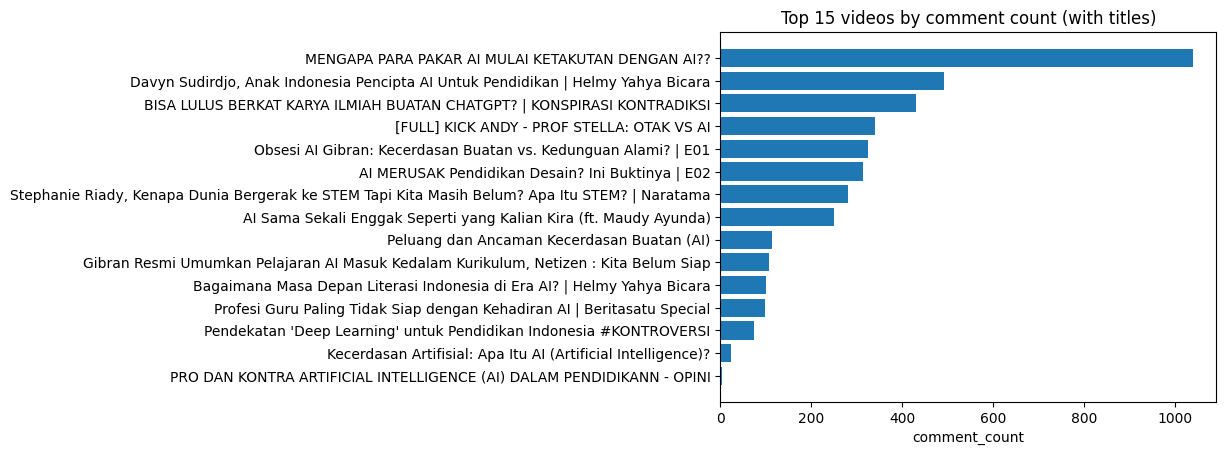

- MENGAPA PARA PAKAR AI MULAI KETAKUTAN DENGAN AI??
  https://www.youtube.com/watch?v=YaM-Y8RT4us
  comments: 1040

- Davyn Sudirdjo, Anak Indonesia Pencipta AI Untuk Pendidikan | Helmy Yahya Bicara
  https://www.youtube.com/watch?v=RYwFpsaeHDQ
  comments: 492

- BISA LULUS BERKAT KARYA ILMIAH BUATAN CHATGPT? | KONSPIRASI KONTRADIKSI
  https://www.youtube.com/watch?v=W-TbY_Pkjqk
  comments: 430

- [FULL] KICK ANDY - PROF STELLA: OTAK VS AI
  https://www.youtube.com/watch?v=Glvgjr-gPUQ
  comments: 341

- Obsesi AI Gibran: Kecerdasan Buatan vs. Kedunguan Alami? | E01
  https://www.youtube.com/watch?v=DD00i0aYjl4
  comments: 324

- AI MERUSAK Pendidikan Desain? Ini Buktinya | E02
  https://www.youtube.com/watch?v=yISBczwiAsg
  comments: 314

- Stephanie Riady, Kenapa Dunia Bergerak ke STEM Tapi Kita Masih Belum? Apa Itu STEM? | Naratama
  https://www.youtube.com/watch?v=8xzl337mEJg
  comments: 281

- AI Sama Sekali Enggak Seperti yang Kalian Kira (ft. Maudy Ayunda)
  https://www.youtube.c

In [8]:
# Ambil 15 video teratas berdasarkan jumlah komentar (dari video_summary yang sudah dibuat)
top = video_summary.head(15).copy()

# Siapkan label untuk sumbu-Y: jika judul kosong, ganti jadi "(no title)" biar plot tetap rapi
labels = top["video_title"].replace("", "(no title)").tolist()

# Plot bar horizontal untuk melihat distribusi komentar per video (Top 15)
plt.figure()
plt.barh(range(len(top)), top["comment_count"].values)
plt.yticks(range(len(top)), labels)          # tampilkan judul video sebagai label di sumbu Y
plt.title("Top 15 videos by comment count (with titles)")
plt.xlabel("comment_count")
plt.gca().invert_yaxis()                     # video dengan komentar terbanyak muncul di paling atas
plt.show()

# Print ringkasan teks per video: judul + URL + total komentar (untuk trace balik saat analisis/persona)
for _, r in top.iterrows():
    # Guard: kalau judul kosong/blank, tampilkan placeholder
    title = r["video_title"] if isinstance(r["video_title"], str) and r["video_title"].strip() else "(no title)"
    print(f"- {title}\n  {r['video_url']}\n  comments: {r['comment_count']}\n")

Berdasarkan ringkasan Top 15 videos by comment count, terlihat bahwa sebagian besar komentar terkonsentrasi pada beberapa video tertentu, terutama video dengan engagement tinggi seperti MENGAPA PARA PAKAR AI MULAI KETAKUTAN DENGAN AI??. Seperti yang saya jelaskan sebelumnya saat saya scraping datanya, saya sadar bahwa judul "MENGAPA PARA PAKAR AI MULAI KETAKUTAN DENGAN AI??", "Kecerdasan Artifisial: Apa itu AI", dan AI Sama Sekali Enggak Seperti yang Kalian Kira cenderung bersifat umum (membahas AI secara luas), sehingga secara topik awal sebenarnya kurang relevan dengan fokus tugas.

Namun, saya tetap memasukkan video-video tersebut pada tahap scraping karena jumlah komentarnya sangat banyak. Dengan volume komentar yang besar, saya ingin memanfaatkan peluang bahwa di dalam diskusi umum tentang AI tersebut tetap ada sebagian komentar yang menyinggung konteks pendidikan, misalnya pengalaman siswa/mahasiswa menggunakan AI, kekhawatiran guru/dosen, penggunaan AI untuk tugas/ujian, hingga isu kurikulum dan pembelajaran.

Karena itu, video-video yang kurang relevan ini saya perlakukan sebagai "sumber kandidat", bukan sumber utama. Setelah data terkumpul, saya akan melakukan filtering ulang pada tahap EDA dan preprocessing untuk menyaring kembali komentar yang benar-benar membahas pendidikan, sehingga dataset akhir lebih tepat sasaran. Saya sengaja menargetkan 4000 komentar di awal agar setelah dilakukan penyaringan lebih ketat (termasuk chunking untuk komentar panjang), jumlah data yang tersisa tetap cukup besar dan stabil untuk pemodelan unsupervised learning, minimal masih di atas 1000 komentar -> target

## Refilter

In [9]:
# Keyword pendidikan
EDU_TERMS_BASE = [
    "pendidikan","sekolah","kampus","guru","dosen","siswa","mahasiswa",
    "kurikulum","pembelajaran","belajar","tugas","ujian"
]

EDU_TERMS_EXTRA = [
    # konteks akademik umum
    "kuliah","kelas","murid","pelajar","pelajaran","edukasi","mengajar","pengajar",
    # tugas/assessment
    "pr","kuis","uts","uas","nilai","rapor","penilaian","evaluasi","lks","modul",
    # karya ilmiah
    "skripsi","tesis","disertasi","karya ilmiah","jurnal","paper","sitasi","referensi",
    # isu perilaku akademik
    "plagiar","plagiarism","mencontek","contekan","kejujuran akademik",
    "kemdikbud","merdeka belajar","kurikulum merdeka"
]

EDU_TERMS = sorted(set(EDU_TERMS_BASE + EDU_TERMS_EXTRA), key=len, reverse=True)

def _term_to_pattern(t: str) -> str:
    t = t.lower().strip()
    # frasa multi-kata: spasi dibuat fleksibel
    if " " in t or "" in t:
        return re.escape(t).replace(r"\ ", r"\s+")
    # token pendek: pakai boundary biar ga nyasar (mis. "pr", "uts", "uas")
    if len(t) <= 5:
        return rf"\b{re.escape(t)}\b"
    return re.escape(t)

EDU_PAT = "(" + "|".join([_term_to_pattern(t) for t in EDU_TERMS]) + ")"
edu_re = re.compile(EDU_PAT, flags=re.IGNORECASE)

print("Total EDU_TERMS:", len(EDU_TERMS))
print("Regex ready.")

Total EDU_TERMS: 46
Regex ready.


Cara menerapkannya, saya melakukan penyaringan ulang komentar agar dataset lebih relevan dengan topik AI dalam pendidikan. Saya mendefinisikan dua kelompok keyword:

EDU_TERMS_BASE: kata-kata inti pendidikan (pendidikan, sekolah, kampus, guru/dosen, siswa/mahasiswa, kurikulum, belajar, tugas, ujian).

EDU_TERMS_EXTRA: kata tambahan yang masih satu konteks (kuliah/kelas, PR/kuis/UTS/UAS, penilaian, skripsi/tesis, plagiarisme/mencontek, serta istilah kebijakan seperti Kemdikbud dan Merdeka Belajar).

Kemudian semua keyword digabung dan dibuat menjadi regex (edu_re) untuk menandai komentar yang mengandung minimal satu keyword pendidikan. Hasilnya, saya mendapatkan subset komentar yang nyebut pendidikan, sehingga data yang dipakai untuk clustering dan topic extraction lebih fokus dan tidak terlalu banyak noise dari diskusi AI yang umum.

### Normalisasi teks + filtering (df_edu)

In [10]:
# Pastikan text string + normalisasi ringan untuk matching
df["text"] = df["text"].astype(str)
df["text_norm"] = (
    df["text"]
      .str.lower()
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)

# Flag: minimal ada 1 keyword pendidikan
df["edu_hit"] = df["text_norm"].apply(lambda s: bool(edu_re.search(s)))

# Subset hasil filter
df_edu = df[df["edu_hit"]].copy()

print("[EDU FILTER]")
print("Total komentar:", len(df))
print("Lolos (ada keyword pendidikan):", len(df_edu), f"({len(df_edu)/len(df)*100:.1f}%)")

[EDU FILTER]
Total komentar: 4000
Lolos (ada keyword pendidikan): 1679 (42.0%)


Saya normalisasi teks (`text_norm`) dengan cara mengubah huruf menjadi lowercase, merapikan spasi berlebih, dan trimming, supaya pencarian keyword lebih konsisten. Lalu saya membuat flag `edu_hit` yang bernilai True jika komentar mengandung minimal satu keyword pendidikan (berdasarkan regex `edu_re`).

Hasilnya, dari total 4000 komentar, terdapat **1679 komentar (42.0%)** yang lolos karena mengandung kata-kata terkait pendidikan. Subset `df_edu` inilah yang akan saya gunakan untuk preprocessing lanjutan (termasuk chunking) dan pemodelan unsupervised, sehingga analisis lebih fokus pada topik AI dalam pendidikan dan mengurangi noise dari komentar AI yang terlalu umum.


### Ringkasan per video + preview + simpan CSV

In [11]:
# Buat mapping video_id -> video_title, lalu tambahkan ke dataset supaya interpretasi lebih mudah
unique_vids = df_edu["video_id"].dropna().unique().tolist()
title_map = {vid: fetch_title_oembed(vid) for vid in unique_vids}

df_edu["video_title"] = df_edu["video_id"].map(title_map).fillna("")
df_edu[["video_id", "video_title"]].drop_duplicates().head(10)

# Ringkasan jumlah komentar pendidikan per video
if "video_id" in df_edu.columns:
    edu_by_video = (
        df_edu.groupby(["video_id", "video_title"], dropna=False)
              .size()
              .reset_index(name="edu_comment_count")
              .sort_values("edu_comment_count", ascending=False)
    )
    display(edu_by_video.head(15))

# Preview komentar yang lolos
display(df_edu[["video_title","relevance_score","text"]].head(10))

# Simpan hasil filter untuk step preprocessing/chunking berikutnya
OUT_EDU = "yt_comments_edu_filtered.csv"
df_edu.drop(columns=["text_norm"], errors="ignore").to_csv(OUT_EDU, index=False, encoding="utf-8-sig")
print("Saved:", OUT_EDU)

,video_id,video_title,edu_comment_count
7,RYwFpsaeHDQ,"Davyn Sudirdjo, Anak Indonesia Pencipta AI Unt...",252
0,8xzl337mEJg,"Stephanie Riady, Kenapa Dunia Bergerak ke STEM...",224
3,Glvgjr-gPUQ,[FULL] KICK ANDY - PROF STELLA: OTAK VS AI,224
13,YaM-Y8RT4us,MENGAPA PARA PAKAR AI MULAI KETAKUTAN DENGAN AI??,208
1,DD00i0aYjl4,Obsesi AI Gibran: Kecerdasan Buatan vs. Kedung...,160
16,yISBczwiAsg,AI MERUSAK Pendidikan Desain? Ini Buktinya | E02,144
12,YSMuusyVR14,Profesi Guru Paling Tidak Siap dengan Kehadira...,88
8,S9qkBcOI-o4,Gibran Resmi Umumkan Pelajaran AI Masuk Kedala...,81
14,_FcHPrRY5zg,AI Sama Sekali Enggak Seperti yang Kalian Kira...,71
5,Mh0kKZoiA18,Pendekatan 'Deep Learning' untuk Pendidikan In...,69


,video_title,relevance_score,text
0,BISA LULUS BERKAT KARYA ILMIAH BUATAN CHATGPT?...,9,Guru tugasnya balik nguliti AI. Serta menjaga ...
2,BISA LULUS BERKAT KARYA ILMIAH BUATAN CHATGPT?...,8,selama AI dibatasi menyimpan data dan membuat ...
3,BISA LULUS BERKAT KARYA ILMIAH BUATAN CHATGPT?...,9,jk digunakan o/ Penjahat a/ jd kejahatan bsr ...
4,BISA LULUS BERKAT KARYA ILMIAH BUATAN CHATGPT?...,9,"AI lambat laun akan menjadi kebuthan manusia ,..."
5,BISA LULUS BERKAT KARYA ILMIAH BUATAN CHATGPT?...,8,Perlu juga belajar limitation \n chat gpt utk ...
6,BISA LULUS BERKAT KARYA ILMIAH BUATAN CHATGPT?...,11,dampak positif Ai pada bidang pendidikan terut...
7,BISA LULUS BERKAT KARYA ILMIAH BUATAN CHATGPT?...,11,Nama: Indah Purnamasari\nNPM: 2061201146\nKela...
8,BISA LULUS BERKAT KARYA ILMIAH BUATAN CHATGPT?...,11,Nama\t: Alisanabela Nasrun\nNPM\t: 2161201032\...
9,BISA LULUS BERKAT KARYA ILMIAH BUATAN CHATGPT?...,11,AI atau Artificial Intelligence dapat memberik...
10,BISA LULUS BERKAT KARYA ILMIAH BUATAN CHATGPT?...,9,"chatgpt gak akan bikin programmer selesai sih,..."


Saved: yt_comments_edu_filtered.csv


### Panjang teks (char & word) + histogram word_len

,char_len,word_len
count,1679.000000,1679.000000
mean,421.778440,62.285884
std,596.082098,84.599212
min,18.000000,2.000000
50%,244.000000,36.000000
75%,468.000000,72.000000
90%,936.800000,140.000000
95%,1388.200000,205.000000
99%,2547.200000,370.660000
max,9980.000000,1367.000000


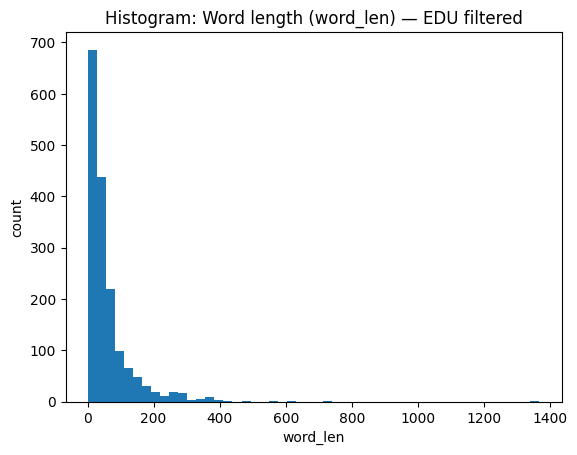

In [12]:
# Pastikan kolom text bertipe string
df_edu["text"] = df_edu["text"].astype(str)

# Hitung panjang komentar dalam karakter
df_edu["char_len"] = df_edu["text"].str.len()

# Hitung panjang komentar dalam kata (word count sederhana)
df_edu["word_len"] = df_edu["text"].apply(lambda x: len(re.findall(r"\w+", x)))

# Ringkasan statistik + persentil
display(df_edu[["char_len", "word_len"]].describe(percentiles=[.5, .75, .9, .95, .99]))

# Histogram word_len
plt.figure()
plt.hist(df_edu["word_len"], bins=50)
plt.title("Histogram: Word length (word_len) — EDU filtered")
plt.xlabel("word_len")
plt.ylabel("count")
plt.show()

Distribusi panjang komentar sangat miring ke kanan (right-skewed): mayoritas komentar pendek, tapi ada sedikit komentar sangat panjang (outlier) yang membentuk ekor panjang di histogram.

Median: 244 karakter / 36 kata -> ini panjang tipikal pada dataset (EDU-filtered).
75%: ≤ 468 karakter / 72 kata.
95%: ≤ 1388.2 karakter / 205 kata.
99%: ≤ 2547.2 karakter / 370.66 kata.
Maksimum ekstrem: 9980 karakter / 1367 kata -> outlier.

Ini perlu ditangani karena mean lebih besar dari median karena ketarik komentar ekstrem.

Jika dibiarkan, komentar panjang bisa mendominasi representasi teks dan mengganggu clustering/topic modeling (karena membawa banyak ide sekaligus).

Penanganan:

Saya akan pakai chunking untuk memecah komentar panjang jadi beberapa potongan agar panjang lebih seragam dan isi tiap unit lebih fokus.

### Top 15 video by comment count (untuk df_edu)

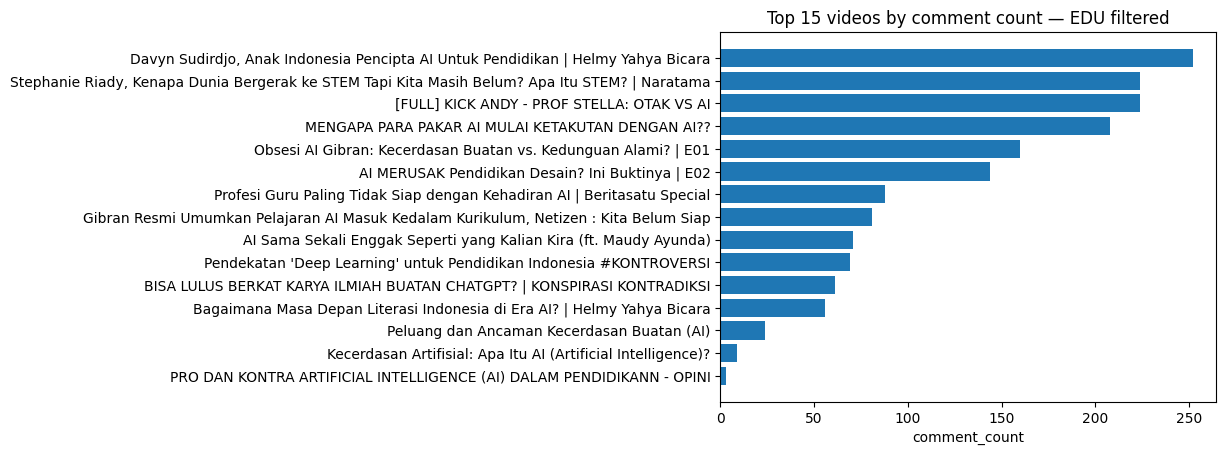

- Davyn Sudirdjo, Anak Indonesia Pencipta AI Untuk Pendidikan | Helmy Yahya Bicara
  https://www.youtube.com/watch?v=RYwFpsaeHDQ
  comments: 252

- Stephanie Riady, Kenapa Dunia Bergerak ke STEM Tapi Kita Masih Belum? Apa Itu STEM? | Naratama
  https://www.youtube.com/watch?v=8xzl337mEJg
  comments: 224

- [FULL] KICK ANDY - PROF STELLA: OTAK VS AI
  https://www.youtube.com/watch?v=Glvgjr-gPUQ
  comments: 224

- MENGAPA PARA PAKAR AI MULAI KETAKUTAN DENGAN AI??
  https://www.youtube.com/watch?v=YaM-Y8RT4us
  comments: 208

- Obsesi AI Gibran: Kecerdasan Buatan vs. Kedunguan Alami? | E01
  https://www.youtube.com/watch?v=DD00i0aYjl4
  comments: 160

- AI MERUSAK Pendidikan Desain? Ini Buktinya | E02
  https://www.youtube.com/watch?v=yISBczwiAsg
  comments: 144

- Profesi Guru Paling Tidak Siap dengan Kehadiran AI | Beritasatu Special
  https://www.youtube.com/watch?v=YSMuusyVR14
  comments: 88

- Gibran Resmi Umumkan Pelajaran AI Masuk Kedalam Kurikulum, Netizen : Kita Belum Siap
  http

In [13]:
# Recompute summary per video untuk dataset yang sudah difilter
video_summary_edu = (
    df_edu.groupby(["video_id", "video_title"], dropna=False)
          .size()
          .reset_index(name="comment_count")
          .sort_values("comment_count", ascending=False)
)

# Tambahkan URL video
video_summary_edu["video_url"] = "https://www.youtube.com/watch?v=" + video_summary_edu["video_id"].astype(str)

# Ambil top 15
top_edu = video_summary_edu.head(15).copy()
labels = top_edu["video_title"].replace("", "(no title)").tolist()

# Plot bar horizontal
plt.figure()
plt.barh(range(len(top_edu)), top_edu["comment_count"].values)
plt.yticks(range(len(top_edu)), labels)
plt.title("Top 15 videos by comment count — EDU filtered")
plt.xlabel("comment_count")
plt.gca().invert_yaxis()
plt.show()

# Print detail (judul + link + jumlah komentar)
for _, r in top_edu.iterrows():
    title = r["video_title"] if isinstance(r["video_title"], str) and r["video_title"].strip() else "(no title)"
    print(f"- {title}\n  {r['video_url']}\n  comments: {r['comment_count']}\n")

Setelah EDU filtering (komentar wajib mengandung keyword pendidikan), distribusi komentar per video berubah dan jadi lebih sesuai topik tugas.

Dominasi video AI umum berkurang. Sebelumnya MENGAPA PARA PAKAR AI… mendominasi (1040), sekarang turun jadi 208. Artinya banyak komentar di video itu sebenarnya tidak membahas pendidikan, dan berhasil tersaring.

Video yang konteksnya lebih dekat ke pendidikan sekarang naik ke atas, seperti:
- Davyn Sudirdjo… AI Untuk Pendidikan (252)
- STEM… (224)
- Kick Andy - Otak vs AI (224)

Ini menunjukkan komentar bertema pendidikan paling banyak terkumpul pada video yang memang berkaitan dengan edukasi/literasi/STEM.

Asumsi awal terbukti: video umum tetap punya sebagian komentar pendidikan (mis. MENGAPA PARA PAKAR AI… masih 208), tetapi porsinya lebih kecil. Sementara video definisi AI seperti Apa itu AI tinggal 9 komentar -> memang kurang relevan untuk pendidikan.

Dataset jadi lebih bersih dan lebih merata (tidak ketarik satu video viral), sehingga hasil clustering/topic modeling nanti lebih stabil dan lebih mungkin menghasilkan tema pendidikan (tugas/ujian, guru, kurikulum, literasi/STEM, dsb.).

### Top unigram & bigram (EDU-filtered)

In [14]:
def light_clean(s: str) -> str:
    s = str(s).lower()                          # lowercase biar konsisten
    s = re.sub(r"http\S+|www\.\S+", " ", s)     # buang URL
    s = re.sub(r"[^a-z0-9\s]", " ", s)          # buang simbol (basic)
    s = re.sub(r"\s+", " ", s).strip()          # rapikan spasi
    return s

# cleaning ringan untuk seluruh komentar EDU-filtered
texts_clean_edu = df_edu["text"].map(light_clean)

# Unigram: kata paling sering muncul
cv1 = CountVectorizer(min_df=5, ngram_range=(1,1))
X1 = cv1.fit_transform(texts_clean_edu)
unigrams_edu = pd.Series(X1.sum(axis=0).A1, index=cv1.get_feature_names_out()).sort_values(ascending=False).head(30)
display(unigrams_edu.to_frame("count"))

# Bigram: pasangan kata paling sering muncul
cv2 = CountVectorizer(min_df=5, ngram_range=(2,2))
X2 = cv2.fit_transform(texts_clean_edu)
bigrams_edu = pd.Series(X2.sum(axis=0).A1, index=cv2.get_feature_names_out()).sort_values(ascending=False).head(30)
display(bigrams_edu.to_frame("count"))

,count
dan,2597
yang,2205
ai,2110
di,1604
yg,1304
itu,1098
bisa,1064
untuk,1040
ini,937
tidak,888


,count
di indonesia,146
ai itu,117
apa yang,102
ai dan,86
apa saja,85
tidak akan,83
ai yang,83
tidak bisa,79
pendidikan di,74
salah satu,74


**Unigram (kata tunggal)**
- Kata paling sering masih didominasi kata umum: dan, yang, di, itu, ini, tidak, dengan, saya, kita -> ini wajar karena belum memakai stopwords.
- Kata konten yang relevan pendidikan sudah muncul kuat: ai (2110), pendidikan (773), guru (665), belajar (629), anak (471), indonesia (538).

Artinya, dataset EDU-filtered memang sudah mengarah ke konteks pendidikan, tapi noise kata umum masih menutupi detail tema.

**Bigram (pasangan kata)**

Bigram yang lebih bertema mulai terlihat:
- konteks nasional/kebijakan: di indonesia, masa depan
- konteks pendidikan: dunia pendidikan, pendidikan di, di sekolah
- pemakaian AI: menggunakan ai, penggunaan ai, ai untuk, dengan ai
- aktor pendidikan: anak anak, orang tua

Masih ada bigram generik: apa yang, salah satu, menurut saya -> wajar stopwords belum diterapkan.

**Implikasi & preprocessing**
- TF-IDF: tambah stopwords Indonesia + custom (mis. dan, yang, di, itu, ini, saya, kita, menurut, apa, yg), normalisasi slang (yg->yang), pakai ngram_range=(1,2) dan atur max_df/min_df supaya fitur lebih informatif.
- SBERT: cleaning cukup ringan (hapus URL/rapikan spasi), jangan buang terlalu banyak kata, tetap lakukan dedup + chunking untuk komentar panjang.
- KMEANS (gunakan cosine similarity dan normalisasi (TF-IDF L2) agar tetangga yang mirip semantik lebih akurat.
- BERTopic: pakai embeddings (SBERT) + custom vectorizer (stopwords + bigram) agar kata topik lebih bagus 

## Preprocessing -> a

In [157]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

### Helper cleaning + stopwords

In [16]:
# Stopwords = kata paling dominan dari EDA (biar fitur TF-IDF/ngram lebih "berisi")
# -> Ini daftar stopword custom berbasis hasil EDA (kata yang terlalu sering muncul).
# -> Dipakai nanti di CountVectorizer / TfidfVectorizer (stop_words=...), supaya fitur fokus ke kata bermakna.
STOPWORDS_ID_EDA = set([
    "dan","yang","di","yg","itu","ini","tidak","dengan","kita","saya","untuk","dari",
    "akan","lebih","tapi","atau","apa","karena","orang","dalam","ada","jadi"
])

# remove emoji (tanpa library tambahan)
# -> Regex ini menghapus karakter unicode astral plane (umumnya emoji).
# -> Berguna agar emoji tidak jadi token aneh di TF-IDF/ngram dan tidak bikin noise.
EMOJI_RE = re.compile(r"[\U00010000-\U0010ffff]", flags=re.UNICODE)

def normalize_ws(s: str) -> str:
    # Rapikan whitespace: spasi/tab/newline beruntun jadi 1 spasi, lalu strip di awal/akhir
    return re.sub(r"\s+", " ", str(s)).strip()

def strip_url(s: str) -> str:
    # Buang URL (http... atau www...) karena biasanya noise dan tidak membantu clustering/topik
    return re.sub(r"http\S+|www\.\S+", " ", str(s))

def remove_emoji(s: str) -> str:
    # Hapus emoji pakai regex di atas
    return EMOJI_RE.sub(" ", str(s))

def clean_for_tfidf(s: str) -> str:
    # Cleaning AGRESIF untuk TF-IDF/ngram:
    # - lowercase biar konsisten
    # - buang URL + emoji (noise)
    # - buang simbol/punctuation (sisakan huruf/angka/spasi) supaya token rapi
    # - rapikan spasi
    s = str(s).lower()
    s = strip_url(s)
    s = remove_emoji(s)
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return normalize_ws(s)

def clean_light(s: str) -> str:
    # Cleaning RINGAN untuk chunking / SBERT:
    # - lowercase
    # - buang URL + emoji
    # - TIDAK menghapus semua simbol (lebih aman untuk menjaga konteks kalimat)
    # - rapikan spasi
    s = str(s).lower()
    s = strip_url(s)
    s = remove_emoji(s)
    return normalize_ws(s)

# Pastikan kolom text bertipe string agar aman diproses (hindari NaN / tipe non-string)
df_edu["text"] = df_edu["text"].astype(str)


Selanjutnya, berdasarkan hasil EDA, saya melakukan preprocessing, yaitu:
* **STOPWORDS_ID_EDA** dibuat larena unigram/bigram sebelumnya didominasi kata umum (dan, yang, di, itu, ini). Stopwords ini akan menurunkan dominasi kata umum dan membuat TF-IDF lebih sensitif terhadap kata/topik pendidikan.
* **Remove URL + emoji** URL sering tidak membawa makna topik (noise), dan emoji bisa menjadi token acak yang mengganggu vektor (terutama TF-IDF). Menghapus keduanya bikin representasi lebih stabil.
* **Dua level cleaning**:

  * `clean_for_tfidf()` **agresif** -> cleaning agresif membantu mengurangi variasi palsu (mis. simbol/typo) supaya fitur tidak meledak.
  * `clean_light()` **ringan** -> cleaning cukup ringan, kalau terlalu agresif bisa menghilangkan sinyal konteks.
* `astype(str)` memastikan pipeline aman dari error saat ada nilai non-string.


### Dedup + set kolom clean

In [17]:
# Dedup by normalized text (bagus buat stabilin cluster/topic)
# -> Tujuan dedup: mengurangi komentar yang isinya sama/nyaris sama (spam/copy-paste)
def norm_for_dedup(s: str) -> str:
    # Pakai cleaning LIGHT (bukan agresif) supaya dedup fokus ke kesamaan isi,
    # tapi tetap cukup bersih (URL/emoji dibuang, spasi dirapikan).
    s = clean_light(s)
    return s

# Buat versi teks yang dinormalisasi khusus untuk mendeteksi duplikat
df_edu["text_norm"] = df_edu["text"].map(norm_for_dedup)

# Hitung berapa baris yang terdeteksi duplikat berdasarkan text_norm
dup_n = df_edu.duplicated("text_norm").sum()
print("Rows:", len(df_edu), "| Duplicate (norm text):", dup_n)

# Hapus duplikat dengan tujuan membuat cluster/topic biasanya lebih stabil.
df_edu = df_edu.drop_duplicates("text_norm").copy()

# Siapkan 2 versi teks bersih untuk downstream (sesuai kebutuhan model)
df_edu["text_clean_light"] = df_edu["text"].map(clean_light)     # untuk chunking / SBERT (konteks dijaga)
df_edu["text_clean_tfidf"] = df_edu["text"].map(clean_for_tfidf) # untuk TF-IDF / n-gram (token lebih rapi)


Rows: 1679 | Duplicate (norm text): 25


Sudah bersih dari deduplikasi (yang mirip mirip)

### Chunking

In [18]:
# Dari EDA: 95% komentar punya word_len <= ~205, tapi max bisa sampai 1367
# -> Jadi chunking difokuskan hanya untuk komentar outlier (yang terlalu panjang),
#    supaya unit teks lebih seragam dan tidak campur banyak ide dalam satu baris.
CHUNK_IF_WORDLEN_GE = 205     # threshold chunking (≈ P95 word_len)
CHUNK_SIZE_WORDS = 120        # target ukuran tiap chunk (dalam kata)
CHUNK_OVERLAP = 20            # overlap antar chunk biar konteks nyambung
MIN_CHUNK_WORDS = 15          # stop kalau sisa chunk terlalu pendek (noise)

def chunk_by_words(
    text: str,
    chunk_size=CHUNK_SIZE_WORDS,
    overlap=CHUNK_OVERLAP,
    min_words=MIN_CHUNK_WORDS
):
    # Split berdasarkan kata setelah cleaning ringan (URL/emoji dibuang, spasi rapi).
    words = clean_light(text).split()

    # Kalau teks masih pendek, tidak perlu dipotong: dianggap 1 chunk utuh.
    if len(words) < chunk_size:
        return [clean_light(text)]

    # Step = jarak geser window (chunk_size - overlap).
    # overlap membantu menjaga kontinuitas konteks antar chunk.
    step = max(1, chunk_size - overlap)

    chunks = []
    for start in range(0, len(words), step):
        part = words[start:start + chunk_size]

        # Jika sisa kata terlalu sedikit, hentikan (agar tidak menghasilkan chunk kerdil).
        if len(part) < min_words:
            break

        chunks.append(" ".join(part))
    return chunks

rows = []
for _, r in df_edu.iterrows():
    # Pakai teks versi clean_light yang sudah disiapkan sebelumnya
    base_text = r["text_clean_light"]
    wlen = len(base_text.split())

    # Chunking hanya untuk komentar yang panjang (>= P95)
    if wlen >= CHUNK_IF_WORDLEN_GE:
        parts = chunk_by_words(base_text)

        # Duplikasi metadata komentar aslinya, lalu buat beberapa baris chunk
        for j, ch in enumerate(parts):
            row = r.to_dict()
            row["chunk_id"] = j          # indeks chunk dari komentar yang sama
            row["text_chunk"] = ch       # teks chunk final yang dipakai downstream
            row["is_chunked"] = True     # penanda: baris ini hasil chunking
            rows.append(row)
    else:
        # Untuk komentar normal, tetap 1 baris (tidak dipecah)
        row = r.to_dict()
        row["chunk_id"] = 0
        row["text_chunk"] = base_text
        row["is_chunked"] = False
        rows.append(row)

# Gabungkan semua baris (komentar normal + hasil chunking outlier) jadi satu DataFrame
df_chunks = pd.DataFrame(rows)

print("Before:", len(df_edu), "comments")
print("After :", len(df_chunks), "rows (comment + chunks)")
print("Chunked rows:", int(df_chunks["is_chunked"].sum()))


Before: 1654 comments
After : 1876 rows (comment + chunks)
Chunked rows: 304


Dari, EDA komentar right-skewed (ada outlier sangat panjang sampai 1367 kata), jadi komentar panjang dipecah agar unit teks lebih seragam dan tidak campur banyak ide saat clustering/topic modeling.

* Kapan di-chunk: hanya jika word_len >= 205 (≈ P95), komentar yang lebih pendek tetap 1 baris (tidak dipecah).
* Ukuran & overlap: tiap chunk ~120 kata dengan overlap 20 kata supaya konteks antar potongan tetap nyambung.
* Buang chunk terlalu pendek: jika sisa potongan < 15 kata, proses berhenti agar tidak menghasilkan chunk kecil/noise.
* Output: dibuat df_chunks yang berisi gabungan komentar normal + hasil chunking, dengan kolom chunk_id, text_chunk, is_chunked.
* Hasilnya: 1679 komentar menjadi 1901 baris (comment + chunks), dengan 304 baris berasal dari komentar yang di-chunk.


### Hasil n gram setelah preprocessing

In [19]:
# Tujuan: cek kata/pasangan kata dominan setelah stopwords -> memastikan fitur sudah lebih berisi
cv_uni = CountVectorizer(
    min_df=5,                 # hanya ambil token yang muncul ≥ 5 dokumen (kurangi noise)
    ngram_range=(1,1),        # unigram (1 kata)
    stop_words=list(STOPWORDS_ID_EDA)  # buang kata dominan hasil EDA (dan/yang/di/...)
)
X_uni = cv_uni.fit_transform(df_chunks["text_chunk"])  # ubah teks -> matriks count
unigram_top = (
    pd.Series(X_uni.sum(axis=0).A1, index=cv_uni.get_feature_names_out())  # total frekuensi tiap kata
      .sort_values(ascending=False)
      .head(30)  # top 30 kata
)
display(unigram_top.to_frame("count"))

# Bigram: cek frasa paling sering (lebih informatif dari unigram)
cv_bi = CountVectorizer(
    min_df=5,
    ngram_range=(2,2),        # bigram (2 kata berurutan)
    stop_words=list(STOPWORDS_ID_EDA)
)
X_bi = cv_bi.fit_transform(df_chunks["text_chunk"])
bigram_top = (
    pd.Series(X_bi.sum(axis=0).A1, index=cv_bi.get_feature_names_out())
      .sort_values(ascending=False)
      .head(30)
)
display(bigram_top.to_frame("count"))

,count
ai,2200
bisa,1072
pendidikan,788
manusia,712
guru,668
belajar,649
indonesia,537
anak,463
juga,411
ke,386


,count
pendidikan indonesia,103
ai bisa,96
penggunaan ai,73
menggunakan ai,66
oleh ai,64
anak anak,63
dunia pendidikan,60
masa depan,60
salah satu,59
menurut anda,58


Unigram
- Kata konten utama sudah dominan: ai, pendidikan, guru, belajar, sekolah, anak, indonesia -> ini bagus dan sesuai fokus tugas.
- Masih ada kata umum yang lolos (juga, ke, adalah, mereka, harus, sudah, nya) -> wajar, tapi kalau mau lebih tajam bisa ditambah ke stopwords custom.

Bigram
- Frasa tematik sudah jelas:
  - konteks pendidikan: pendidikan indonesia, dunia pendidikan, sistem pendidikan
  - pemakaian AI: penggunaan ai, menggunakan ai, ai bisa, ai dapat
  - sentimen pro-kontra: dampak positif, positif negatif
  - isu dampak sosial/kerja: tergantikan oleh, pekerjaan manusia
  - skill pendidikan: berpikir kritis
- Ada konteks sumber video seperti prof stella dan istilah chat gpt -> normal untuk komentar YouTube dan bisa membantu pembentukan topik.


### Text Representation #1: TF-IDF (untuk clustering berbasis sparse features)

Untuk memenuhi soal, 2 text representation dan menyiapkan clustering berbasis KMeans, saya pakai dua pendekatan yang saling melengkapi:
- TF-IDF (bag-of-words): merepresentasikan teks sebagai vektor sparse berbasis frekuensi kata/ngram. Representasi ini efektif menangkap kata kunci/topik eksplisit (mis. dunia pendidikan, penggunaan AI), relatif cepat dihitung, dan cocok untuk mengukur kemiripan dokumen dengan cosine similarity karena komentar yang mirip biasanya berbagi term penting.

- SBERT embeddings (dense semantic): merepresentasikan teks sebagai vektor dense yang menangkap kemiripan makna, bukan hanya kata yang sama. Ini penting karena komentar dapat menyampaikan ide serupa dengan pilihan kata berbeda. Dengan normalize_embeddings=True, embedding sudah ternormalisasi sehingga cosine similarity menjadi lebih stabil, dan K-Means dapat membentuk cluster berdasarkan kedekatan semantik antar komentar.

In [20]:
# Tujuan: representasi vektor sparse untuk clustering (KMeans) + silhouette (k selection)
tfidf = TfidfVectorizer(
    min_df=5,                 # buang term yang terlalu jarang (noise)
    max_df=0.85,              # buang term yang terlalu sering muncul di >85% dokumen (kurang diskriminatif)
    ngram_range=(1,2),        # pakai unigram + bigram agar menangkap frasa penting
    stop_words=list(STOPWORDS_ID_EDA),
    sublinear_tf=True,        # tf = 1 + log(tf) -> menahan efek kata yang berulang banyak
    norm="l2"                 # normalisasi L2 (bagus untuk cosine-like behavior)
)
X_tfidf = tfidf.fit_transform(df_chunks["text_chunk"])
print("TF-IDF shape:", X_tfidf.shape)  # (n_docs, n_features)

TF-IDF shape: (1876, 3409)


Hasilnya:
- 1876 dokumen = komentar + hasil chunking (outlier panjang dipecah, jadi row bertambah dari 1679).
- 3409 fitur = jumlah unigram+bigram yang lolos filter min_df/max_df + stopwords.
- Ini ukuran yang masuk akal untuk sanity check KMeans + elbow/silhouette, dan biasanya sudah cukup untuk clustering awal.

### Text Representation #2: SBERT embeddings + BERTopic-ready

In [21]:
from sentence_transformers import SentenceTransformer  # library untuk membuat embedding kalimat (representasi semantik)

sbert = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")  # load model SBERT multilingual
X_sbert = sbert.encode(
    df_chunks["text_chunk"].tolist(),   # input: list teks (pakai hasil chunking)
    batch_size=64,                      # encode per-batch biar lebih cepat/hemat memori
    show_progress_bar=True,             # tampilkan progress encoding
    normalize_embeddings=True           # normalisasi vektor (L2) -> cocok untuk cosine similarity/clustering
)
print("SBERT shape:", X_sbert.shape)    # output: (jumlah teks, dimensi embedding) mis. (1901, 384)

Batches:   0%|          | 0/30 [00:00<?, ?it/s]

SBERT shape: (1876, 384)


SBERT shape: (1876, 384) artinya ada 1901 baris teks yang direpresentasikan (setelah chunking), dan setiap baris berubah menjadi vektor berdimensi 384.

Dimensi 384 ini bawaan model paraphrase-multilingual-MiniLM-L12-v2.

Embedding SBERT ini menangkap kemiripan semantik (makna), jadi biasanya lebih nyambung untuk clustering/topik dibanding TF-IDF yang lebih berbasis kata.

### KMeans -> b

Kenapa saya pilih K-mens?

K-Means dipilih karena sesuai dengan kebutuhan soal yang meminta kita mencoba beberapa jumlah cluster (k) dan membandingkannya secara kuantitatif. K-Means adalah metode clustering yang sederhana, cepat, dan stabil untuk baseline, sehingga cocok dipakai pada dataset komentar yang ukurannya cukup besar. Selain itu, K-Means punya objective yang jelas (meminimalkan jarak intra-cluster), sehingga hasilnya mudah dievaluasi dan dibandingkan antar nilai k menggunakan metrik seperti silhouette score dan juga inspeksi elbow dari inertia. Dengan dua text representation yang berbeda, K-Means juga memudahkan eksperimen: pada TF-IDF cluster terbentuk dari kemiripan kata/frasal, sedangkan pada SBERT cluster terbentuk dari kedekatan makna (semantik). Karena alasan ini, K-Means menjadi baseline yang kuat dan mudah dipertanggungjawabkan untuk menentukan jumlah cluster terbaik sebelum lanjut ke peronsa analysis

---

Cara kerja K-Means:
1. Kita tentuin dulu jumlah cluster: K.
2. K-Means memilih K titik awal yang disebut centroid (pusat cluster). Biasanya pakai metode k-means++ supaya awalnya lebih bagus.
3. Assign step: setiap data (komentar yang sudah jadi vektor TF-IDF / SBERT) dimasukkan ke cluster dengan centroid terdekat.
4. Update step: centroid dihitung ulang sebagai rata-rata (mean) dari semua titik di cluster itu.
5. Ulangi langkah 3-4 sampai stabil (label tidak berubah lagi) atau sampai mencapai MAX_ITER.

---


Kenapa K-Means niii cocok sebagai baseline???
- Simple dan cepat untuk data besar.
- Mudah dibandingkan antar nilai K (k=2,3,4,...), sesuai tuntutan soal uji beberapa nilai k.
- Enak buat evaluasi awal pakai silhouette score dan elbow (inertia)

#### Imports & Config K-Means

In [44]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Reproducibility: supaya hasil clustering konsisten saat dijalankan ulang
RANDOM_STATE = 42

# KMeans diulang beberapa kali dengan centroid awal berbeda,
# lalu dipilih hasil terbaik (lebih stabil daripada n_init=1)
N_INIT = 10

# Batas maksimum iterasi per run sampai konvergen
MAX_ITER = 300

# Kandidat jumlah cluster (k) yang akan diuji untuk mencari struktur terbaik
# (nanti dibandingkan pakai silhouette score + inertia/elbow)
K_LIST = [2, 3, 4, 5, 6, 7, 8, 9]

- RANDOM_STATE: random seed supaya bisa reproducible

- N_INIT: K-Means sensitif terhadap centroid awal (bisa jatuh ke solusi lokal). 
  Jadi algoritma di-run beberapa kali dengan inisialisasi berbeda, lalu dipilih hasil terbaik (biasanya inertia paling kecil). Semakin besar n_init, semakin stabil, tapi makin lama.

- MAX_ITER: Batas maksimal iterasi assign+update. Biasanya K-Means konvergen sebelum 300, tapi ini untuk jaga-jaga kalau datanya sulit.

- K_LIST: Karena K-Means harus diberi jumlah cluster dari awal, kita coba beberapa K.

Nanti kita bandingkan hasilnya:
  - Silhouette score (semakin tinggi semakin baik) untuk kualitas pemisahan cluster
  - Inertia (semakin kecil semakin rapat) untuk elbow method
  - Persona Anaysis untuk mengetahui karakteristik tiap kelas

#### Helper evaluasi KMeans (silhouette+SSE)

Di eksperimen ini saya memakai inisialisasi k-means++ (init="k-means++"), karena pemilihan centroid awal sangat mempengaruhi hasil akhir K-Means (bisa nyangkut di local optimum dan hasil cluster jadi tidak stabil kalau awalnya jelek). k-means++ memilih centroid awal dengan cara menyebar (lebih jauh satu sama lain), sehingga biasanya konvergensi lebih cepat dan kualitas cluster lebih baik dibanding inisialisasi random.

Bedanya dengan random sebenarnya cuma cara memilih centroid awal:
- Random init: centroid awal dipilih acak -> berisiko beberapa centroid terlalu dekat / jatuh di area padat yang sama.
- k-means++: centroid awal dipilih bertahap dengan peluang lebih besar untuk titik yang jauh dari centroid yang sudah dipilih -> lebih tersebar.

Kelihatannya kecil, tapi efeknya bisa signifikan: hasil jadi lebih konsisten antar run, inertia lebih bagus, dan silhouette cenderung lebih stabil.

In [45]:
def kmeans_grid_eval(X, k_list, name="", metric="cosine"):
    """
    Jalankan K-Means untuk beberapa nilai k, lalu hitung:
    - silhouette score (pakai metric pilihan, default cosine)
    - inertia (SSE internal K-Means makin kecil makin rapat)
    """
    rows = []

    for k in k_list:
        km = KMeans(
            n_clusters=k,
            init="k-means++",      # inisialisasi centroid yang lebih stabil
            n_init=N_INIT,         # run beberapa kali, pilih terbaik (mengurangi efek random)
            random_state=RANDOM_STATE,
            max_iter=MAX_ITER
        )

        # Fit + assign label cluster
        labels = km.fit_predict(X)

        # Silhouette untuk kualitas pemisahan cluster
        # Metric cosine cocok untuk TF-IDF/SBERT yang sudah L2-normalized
        sil = silhouette_score(X, labels, metric=metric)

        # Inertia = total SSE terhadap centroid (selalu Euclidean based untuk KMeans)
        inert = km.inertia_

        rows.append({
            "repr": name,
            "k": k,
            "silhouette": float(sil),
            "inertia": float(inert)
        })

        print(f"[{name}] k={k:>2} | silhouette({metric})={sil:.4f} | inertia={inert:.2f}")

    return pd.DataFrame(rows)

Next, saya melakukan penfujian terhadap beberapa kandidat jumlah cluster (k) menggunakan **K-Means**. Karena kita belum tahu berapa jumlah cluster yang paling masuk akal untuk komentar YouTube, maka saya mencoba `k` dalam sebuah daftar (mis. 2 sampai 9), lalu mengevaluasi hasilnya dengan dua metrik:

1. Silhouette Score (metric = cosine)

* **Silhouette score** mengukur kualitas pemisahan cluster:

  * Nilai mendekati **1**: cluster terpisah jelas dan anggotanya kompak.
  * Nilai mendekati **0**: banyak overlap antar cluster.
  * Nilai negatif: banyak data lebih dekat ke cluster lain (cluster kurang baik).
* Saya memakai **cosine** karena:

  * TF-IDF dan embedding SBERT biasanya lebih cocok dibanding Euclidean untuk teks, sebab yang penting adalah arah/kemiripan makna, bukan besar vektor.
  * Jika embedding sudah **L2-normalized** (misalnya `normalize_embeddings=True` pada SBERT), cosine similarity menjadi lebih stabil.

2. Inertia (SSE K-Means)

* **Inertia** adalah total **Sum of Squared Errors (SSE)** dari jarak setiap titik ke centroid clusternya.
* Semakin kecil inertia -> cluster makin rapat.
* Namun inertia **pasti turun** ketika `k` makin besar, jadi inertia dipakai dengan konsep **elbow method**:

  * Cari titik siku di mana penurunan inertia mulai melambat -> kandidat `k` yang masuk akal.

3. Persona Analysis -> c

Selain metrik kuantitatif (silhouette & inertia), saya juga melakukan penilaian kualitatif untuk memastikan cluster yang terbentuk bermakna dan bisa dijelaskan. Karena tujuan akhir tugas adalah memahami opini publik, maka cluster yang bagus tidak hanya skor tinggi, tetapi juga koheren secara tema.

### Jalankan Training untuk Kedua Text Representation

#### KMeans grid (TF-IDF & SBERT)

In [57]:
# Jalankan evaluasi K-Means untuk representasi TF-IDF
# - X_tfidf: fitur teks berbasis kata/ngram (sparse)
# - K_LIST : daftar kandidat jumlah cluster yang ingin diuji
# - metric="cosine": silhouette dihitung pakai cosine (cocok untuk teks yang sudah L2-normalized)
res_tfidf = kmeans_grid_eval(
    X_tfidf,
    K_LIST,
    name="TFIDF",
    metric="cosine"
)

# Jalankan evaluasi K-Means untuk representasi SBERT
# - X_sbert: embedding semantik (dense) dari SBERT
# - metric="cosine": silhouette pakai cosine agar menilai kemiripan arah/semantik
res_sbert = kmeans_grid_eval(
    X_sbert,
    K_LIST,
    name="SBERT",
    metric="cosine"
)


[TFIDF] k= 2 | silhouette(cosine)=0.0118 | inertia=1816.27
[TFIDF] k= 3 | silhouette(cosine)=0.0087 | inertia=1803.85
[TFIDF] k= 4 | silhouette(cosine)=0.0096 | inertia=1794.78
[TFIDF] k= 5 | silhouette(cosine)=0.0127 | inertia=1786.53
[TFIDF] k= 6 | silhouette(cosine)=0.0136 | inertia=1780.93
[TFIDF] k= 7 | silhouette(cosine)=0.0139 | inertia=1776.18
[TFIDF] k= 8 | silhouette(cosine)=0.0143 | inertia=1772.50
[TFIDF] k= 9 | silhouette(cosine)=0.0136 | inertia=1768.38
[SBERT] k= 2 | silhouette(cosine)=0.1301 | inertia=1164.45
[SBERT] k= 3 | silhouette(cosine)=0.1178 | inertia=1103.22
[SBERT] k= 4 | silhouette(cosine)=0.1200 | inertia=1074.78
[SBERT] k= 5 | silhouette(cosine)=0.1134 | inertia=1050.30
[SBERT] k= 6 | silhouette(cosine)=0.1126 | inertia=1031.88
[SBERT] k= 7 | silhouette(cosine)=0.1064 | inertia=1015.76
[SBERT] k= 8 | silhouette(cosine)=0.0900 | inertia=1002.70
[SBERT] k= 9 | silhouette(cosine)=0.0872 | inertia=992.20



Saya menjalankan evaluasi K-Means pada dua representasi teks: TF-IDF dan SBERT. Nantinya akan diuji nilai k terbaiknya berapa

Untuk setiap nilai k, fungsi kmeans_grid_eval() melakukan:
- Melatih model K-Means dan menghasilkan label cluster untuk setiap komentar/chunk.
- Menghitung silhouette score menggunakan metric cosine untuk menilai seberapa baik pemisahan cluster.
- Mengambil inertia (SSE internal K-Means) sebagai indikator seberapa rapat cluster terhadap centroid.

Hasil evaluasi untuk TF-IDF disimpan pada res_tfidf, sedangkan hasil evaluasi untuk SBERT disimpan pada res_sbert. Kedua output ini berbentuk DataFrame sehingga memudahkan perbandingan antar k dan antar representasi.

Seperti yang sudah saya sebutkan sebelumnya saya gunakan cosine pada silhouette karena TF-IDF dan embedding SBERT biasanya dinormalisasi (L2), dan pada data teks kita lebih peduli pada kemiripan arah/makna dibandingkan jarak Euclidean murni. Setelah mendapatkan nilai silhouette dan inertia, saya memilih kandidat k yang paling masuk akal (nilai silhouette relatif lebih tinggi dan inertia menunjukkan pola elbow), lalu memvalidasi hasilnya menggunakan human judgment melalui persona analysis. Untuk menentukan nilai k terbaiknya, mari kita lihat plot  skor silhouette di setiap k dan pada kedua representasi teks

#### TF-IDF: Silhouette & Inertia vs k

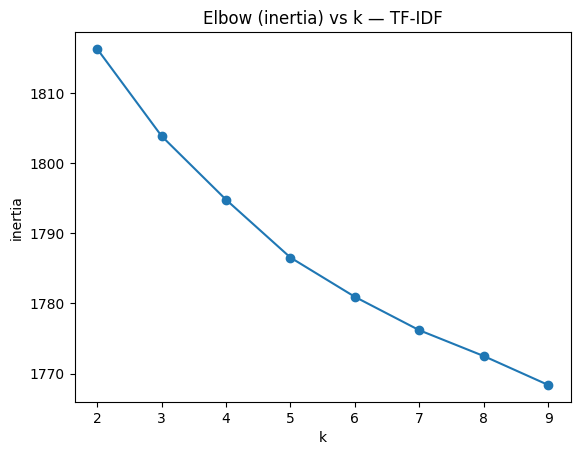

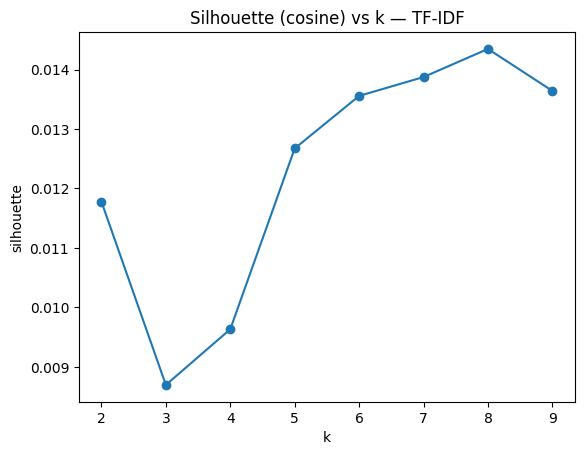

In [64]:
# Plot Elbow (Inertia) vs k (TF-IDF)
plt.figure()
plt.plot(
    res_tfidf["k"],          # sumbu-X: kandidat jumlah clusteri
    res_tfidf["inertia"],    # sumbu-Y: inertia/SSE (semakin kecil semakin rapat di dalam cluster)
    marker="o"
)
plt.title("Elbow (inertia) vs k — TF-IDF")  # judul elbow chart
plt.xlabel("k")
plt.ylabel("inertia")
plt.show()

# Plot Silhouette vs k (TF-IDF)
plt.figure()  
plt.plot(
    res_tfidf["k"],               # sumbu-X: kandidat jumlah cluster
    res_tfidf["silhouette"],      # sumbu-Y: nilai silhouette (cosine) tiap k
    marker="o"                    # kasih marker titik biar tren gampang dibaca
)
plt.title("Silhouette (cosine) vs k — TF-IDF")  # judul grafik
plt.xlabel("k")                                # label sumbu X
plt.ylabel("silhouette")                       # label sumbu Y
plt.show()                                     # tampilkan plot


**Intertia vs k**

BIsa kita lihat, inertia **pasti turun** saat k naik (centroid makin banyak -> SSE makin kecil). Tapi apa yang kita cari? Titik penurunan mulai melandai (elbow), artinya tambah cluster tidak memberi perbaikan besar lagi. Dari grafik, penurunan terlihat cukup tajam sampai sekitar **k=5-6**, lalu mulai lebih landai di **k=6-9**. Ini **cukup konsisten** dengan pilihan silhouette yang cenderung optimal di **k≈8** (kompromi antara pemisahan dan kompleksitas).

---

**Silhouette vs k**

Nilai silhouettenya yang didapatkan sangatlah kecil (~0.009-0.014). Ini berarti **cluster dari TF-IDF belum terpisah jelas** (banyak overlap antar cluster). Meski kecil, silhouette masih berguna untuk **membandingkan k secara relatif** (pilih k dengan nilai paling tinggi pada rentang yang diuji). Dari grafik, silhouette **naik stabil setelah k=4** dan **puncak di sekitar k=8**, lalu turun sedikit di k=9. Maka untuk baseline TF-IDF, kandidat terbaik dari silhouette adalah **k = 8**.


---

**Kesimpulan baseline TF-IDF**

**TF-IDF baseline menghasilkan silhouette rendah**, artinya pemisahan cluster kurang kuat. Ini masih **wajar untuk komentar YouTube** karena topiknya sering overlap (mis. AI untuk tugas/ujian + etika + guru + kurikulum bisa muncul dalam satu komentar) dan banyak variasi gaya bahasa. Berdasarkan perbandingan silhouette pada rentang k yang diuji, **k = 8** dipilih sebagai baseline TF-IDF karena memberikan **nilai silhouette tertinggi**.

---

**Human Juudgment untuk sanity check (cek kualitas cluster secara manual)**
- Untuk memastikan cluster tidak asal, saya ambil **±10 komentar per cluster** (sampling acak dari `df_chunks`), baca isi komentar untuk melihat apakah ada **tema yang konsisten**, buat **label/persona cluster** secara manual (contoh: AI bantu tugas, kekhawatiran guru, etika & plagiarisme, AI gantikan pekerjaan, dll.)

---

Karena skor silhouette TF-IDF **sangat rendah**, persona analysis dari TF-IDF akan **lebih sulit dan kurang stabil** (tema mudah bercampur). Jadi TF-IDF ini saya perlakukan sebagai **baseline awal**, tetapi saya akan **hold dulu** untuk analisis persona yang lebih dalam. Selanjutnya saya akan **fokus evaluasi clustering SBERT**, karena embeddings semantik seharusnya secara logika dan teorinya bisa menghasilkan cluster yang **lebih koheren** untuk komentar pendek dan beragam seperti YouTube.

#### SBERT: Silhouette & Inertia vs k

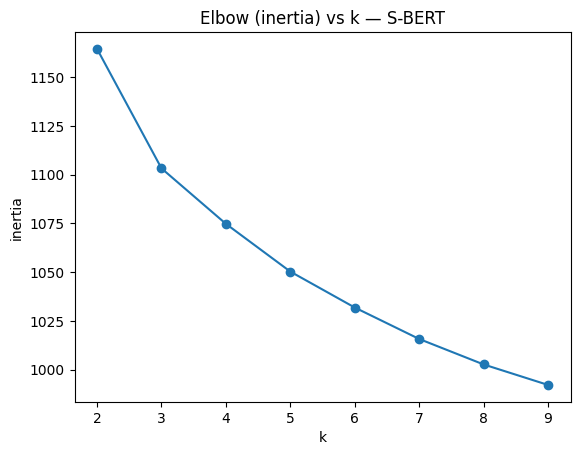

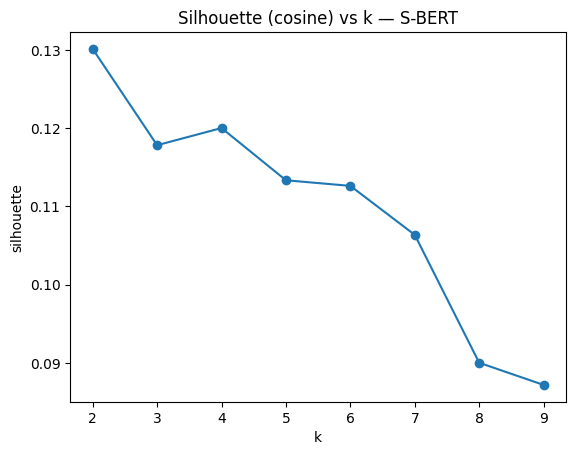

In [65]:
# Plot Elbow (Inertia) vs k (S-BERT)
plt.figure()
plt.plot(
    res_sbert["k"],          # sumbu-X: kandidat jumlah clustering
    res_sbert["inertia"],    # sumbu-Y: inertia/SSE (semakin kecil semakin rapat di dalam cluster)
    marker="o"
)
plt.title("Elbow (inertia) vs k — S-BERT")  # judul elbow chart
plt.xlabel("k")
plt.ylabel("inertia")
plt.show()

# Plot Silhouette vs k (S-BERT)
plt.figure()  
plt.plot(
    res_sbert["k"],               # sumbu-X: kandidat jumlah cluster
    res_sbert["silhouette"],      # sumbu-Y: nilai silhouette (cosine) tiap k
    marker="o"                    # kasih marker titik biar tren gampang dibaca
)
plt.title("Silhouette (cosine) vs k — S-BERT")  # judul grafik
plt.xlabel("k")                                # label sumbu X
plt.ylabel("silhouette")                       # label sumbu Y
plt.show()                                     # tampilkan plot


**Elbow (Inertia) vs k**

Terlihat, inertia turun tajam dari k=2 -> k=3, lalu masih turun cukup terasa sampai sekitar k=4 atau k=5. Setelah itu penurunannya lebih melandai , indikasi elbow kira-kira di k ≈ 4-5.

---

**Silhouette (cosine) vs k**

Dari hasil diatas, kita dapat melihat silhouette tertinggi ada di k=2 (0.13)  artinya pemisahan cluster paling rapi terjadi saat hanya dibagi jadi 2 kelompok besar. k=4 juga masih cukup tinggi   (~0.12) - ini kandidat bagus kalau kita butuh cluster lebih granular tapi masih relatif stabil. Setelah k ≥ 5, silhouette cenderung turun, dan jatuh cukup jelas di k=8-9, tanda bahwa saat cluster terlalu banyak, KMeans mulai memecah data yang sebenarnya overlap, sehingga batas antar cluster makin kabur.

---

**Perbandingan dengan TF-IDF baseline sebelumnya**

- TF-IDF: silhouette kecil banget (~0.01) -> cluster nyaris tidak terpisah (wajar karena komentar pendek, banyak kata umum, dan topik tumpang tindih).
- SBERT baseline (grafik ini): silhouette naik ke ~0.09-0.13 -> ini jauh lebih baik dan menunjukkan SBERT menangkap kemiripan makna (bukan cuma kata yang sama).

Tap, walaupun terlihat lebih bagus, ini masih jelek karena 0.13 itu masih tergolong rendah untuk clustering yang benar-benar rapi (yang bagus banget seringnya >0.3).

Hal ini mungkin terjadi karena komentar YouTube itu noisy, seringkali 1 komentar bahas banyak ide (campur aduk pro/kontra + politik + sekolah + kerja). Ada template/survey-like (menurut anda, setuju nggak) yang bikin banyak komentar mirip gaya bahasa tapi beda isi, membuat anyak komentar pendek -> sinyal semantik tipis. KMeans asumsi cluster bulat/spherical -> di data teks sering bentuknya tidak spherical, jadi data seperti ini lebih cocok HDBSCAN/BERTopic/UMAP+HDBSCAN untuk struktur topik.

---

**Kesimpulan**

Dibanding TF-IDF baseline, embedding (SBERT) menghasilkan cluster yang lebih terpisah (silhouette naik dari ~0.01 menjadi ~0.09-0.13). Jika berdasarkan silhouette, pilihan paling kuat adalah k=2. Sedangkan berdasarkan elbow, kandidat masuk akal ada di k=4-5.

Kalau ingin membuat analisa yang lebih bertema dengan banyak cluster yang merepresentasikan personanya, kita pilih k=4, tapi kalau ingin lebih mudah untuk dianalisa(karena aku akan cek manual dan time constraint:)) yang aku akan uji adalah k=2 untuk dibuat human judgment analysisnya))

---


Aku akan cek 10 komentar per cluster (ambil sample acak) untuk lihat apakah tiap cluster punya tema yang konsisten. Karena TF-IDF baseline sebelumnya silhouette sangat rendah, aku akan hold dulu persona TF-IDF (takutnya persona-nya campur-aduk dan misleading).

### Persona Analysis & Human Judgement (Cluster) -> S-BERT -> c

In [79]:
# Experiment config (SBERT + KMeans, k=2) 
K = 2                  # jumlah cluster yang ingin dibentuk (di sini: 2 kelompok besar)
RANDOM_STATE = 42      # seed untuk reproducibility (hasil clustering konsisten saat di-run ulang)
N_INIT = 10            # jumlah inisialisasi centroid (ambil solusi terbaik dari 10 start -> lebih stabil)
SAMPLE_PER_CLUSTER = 10  # jumlah contoh komentar yang akan di-sampling per cluster untuk manual check

# KMeans clustering on SBERT embeddings
km_sbert_k2 = KMeans(
    n_clusters=K,          # pakai 2 cluster
    init="k-means++",      # inisialisasi centroid yang lebih baik dibanding random (lebih cepat konvergen)
    n_init=N_INIT,         # ulang beberapa kali untuk mengurangi risiko nyangkut di local optimum
    random_state=RANDOM_STATE  # kunci randomness biar hasil bisa direplikasi
)

labels_k2 = km_sbert_k2.fit_predict(X_sbert)  
# fit_predict = latih KMeans pada embedding SBERT, lalu hasilkan label cluster untuk tiap dokumen
# output: labels_k2 panjangnya = jumlah baris X_sbert (mis. 1901), nilai label di {0,1}


Manual check: ambil 10 sampel komentar per cluster untuk inspeksi tema/persona secara kualitatif. Jumlah cluster: k=2 (sesuai hasil silhouette tertinggi pada baseline).

In [80]:
# Salin df_chunks supaya aman (tidak mengubah dataframe asli)
df_check = df_chunks.copy()

# Tempelkan hasil label KMeans (k=2) ke setiap baris teks/chunk
# labels_k2 panjangnya harus sama dengan jumlah baris df_chunks
df_check["cluster_k2"] = labels_k2

# Tampilkan jumlah anggota per cluster untuk cek distribusi (imbang atau timpang)
print("Cluster counts:")
print(df_check["cluster_k2"].value_counts().sort_index())

Cluster counts:
cluster_k2
0    886
1    990
Name: count, dtype: int64


Terlihat kalau, distribuso Cluster 0 = 886 dan Cluster 1 = 990 -> distribusi cukup seimbang (sekitar 47% vs 53%). Tidak ada cluster yang dominan banget (mis. 95% vs 5%) yang biasanya mengindikasikan KMeans cuma ngumpulin noise.

### Ambil Sample Secara Acak(10)

In [77]:
def sample_cluster_rows(df, cluster_id, n=10, seed=42):
    # Filter baris sesuai cluster_id
    d = df[df["cluster_k2"] == cluster_id].copy()
    # Jaga-jaga kalau isi cluster < n
    n = min(n, len(d))
    # Ambil sample acak
    return d.sample(n=n, random_state=seed)[["cluster_k2", "text_chunk"]]

In [81]:
for cid in sorted(df_check["cluster_k2"].unique()):
    print("\n" + "="*70)
    print(f"CLUSTER {cid} — random {SAMPLE_PER_CLUSTER} samples")
    print("="*70)

    samples = sample_cluster_rows(df_check, cid, n=SAMPLE_PER_CLUSTER, seed=RANDOM_STATE)

    for i, row in enumerate(samples.itertuples(index=False), 1):
        txt = row.text_chunk
        # Potong kalau kepanjangan biar output enak dibaca
        txt_short = txt if len(txt) <= 400 else txt[:400] + " ..."
        print(f"{i:02d}. {txt_short}")


CLUSTER 0 — random 10 samples
01. belajar ai dl kang...
02. yang mengerikan adalah ketika menemukan cara berkembang biaknya sendiri, sehingga mampu membuat peradaban, alasan manusia dapat semaju sekarang adalah menyatukan pecahan gagasan, melalui pertukaran informasi dengan tujuan meningkatkan peradaban yang lebih maju, walaupun ai tidak mempunyai perasaan, tapi dengan pola yang dilakukan ai, mempelajari pola emosi yang dikeluarkan manusia, seperti pemicu  ...
03. pengalaman ngajar koding di jurusan rpl smk itu siswa sulit paham, bgaimana dgn anak sd dan smp ya?
04. buat anak sma ga usah glorifikasi ai. ai cuma salah satu tools aja buat cari materi belajar.​ melatih daya pikir analitis, sistematis, ngerti cara penyelesaian masalah dari otak siswa yang autentik jauh lebih penting! gw gamau dapet karyawan yang kagak bisa mikir, nunggu disuruh doang, nyari solusi tinggal chat gpt tapi kagak ngerti isinya. intinya manusianya mesti punya kerangka berpikir yang bag ...
05. good bang, panuta

## Hasil 10 sample

**CLUSTER 0 (AI sebagai alat belajar + kekhawatiran skill berpikir)**

Dominan isinya:
- Komentar yang bahas AI/ChatGPT langsung dalam konteks belajar/tugas (pakai AI sebagai tool, belajar AI, ngajar koding).
- Banyak nada warning: AI bikin malas berpikir , copy-paste, joki tugas/skripsi, hilangnya kemampuan analitis/runut.
- Ada beberapa yang metaforis/filosofis soal AI (AI berkembang, emosi, peradaban) + sedikit komentar off-topic/random (pemerintahan korup, sering muncul dong.

**CLUSTER 1 (Isu sistem pendidikan Indonesia + kebijakan/figur publik + debat sosial**

Dominan isinya:
- Komentar tentang kondisi pendidikan Indonesia secara makro: kualitas guru, perubahan sistem, STEM, Indonesia maju/mundur.
- Banyak muatan kebijakan/negara: pejabat, korupsi, gaji guru, ijasah palsu, arah pendidikan, institusi.
- Ada komentar yang bentuknya tanya/advokasi (minta program edukasi AI, pertanyaan ke narasumber).

Tone lebih civic discourse: harapan, kritik, debat (bahkan ada yang menghina/emosional).

Persona 0: Isinya banyak ngomongin AI sebagai alat bantu belajar, tapi takut bikin siswa/mahasiswa jadi malas mikir dan cuma copy-paste. Fokusnya ke praktik sehari-hari (tugas, sekolah/kampus, cara belajar) dan pentingnya berpikir kritis/runut.

---

Persona 1: Isinya lebih ke bahas pendidikan Indonesia secara besar: kualitas sistem, kebijakan, guru, etika, sampai isu pejabat/korupsi. Banyak nada kritik + harapan (Indonesia maju/mundur, STEM, perbaikan pendidikan) dan kadang nanya solusi/program.

### Cek konsistensi (Accuracy) 

Seperti yang diminta dikelas, diminta untuk melakukan analisa konsistensi cluster/persona pada model terbaik dalam hal ini adalah KMEANS + SBERT

In [82]:
SAMPLE_PER_CLUSTER = 10
NEW_SEED = 123  # ganti aja (mis. 7, 99, 2026) biar random-nya beda

def sample_cluster_rows(df, cluster_id, n=10, seed=42):
    d = df[df["cluster_k2"] == cluster_id].copy()
    n = min(n, len(d))
    return d.sample(n=n, random_state=seed)[["cluster_k2", "text_chunk"]]

for cid in sorted(df_check["cluster_k2"].unique()):
    print("\n" + "="*70)
    print(f"CLUSTER {cid} — random {SAMPLE_PER_CLUSTER} samples (seed={NEW_SEED})")
    print("="*70)
    samples = sample_cluster_rows(df_check, cid, n=SAMPLE_PER_CLUSTER, seed=NEW_SEED)

    for i, row in enumerate(samples.itertuples(index=False), 1):
        txt = row.text_chunk
        txt_short = txt if len(txt) <= 400 else txt[:400] + " ..."
        print(f"{i:02d}. {txt_short}")


CLUSTER 0 — random 10 samples (seed=123)
01. baik di kemudian hari. kenapa lalu dihubung2kan pernyataan gibran tersebut dengan masalah penggunaan ai untuk menghasilkan karya seni instan dsb. atau dikatakan gibran menyuruh siswa pakai ai tanpa berpikir dan menganalisa ulang. gibran gak ada bicara seperti itu, yang dia maksudkan bukan seperti itu. lalu kenapa kalian narasikan sebaliknya? benar2 jahat kalian semua. pintar tapi jahat, membodoh b ...
02. @axelioyutare4179 bener banget bre. ai terlalu digoreng di tahun ini. padahal mah sebelum tahun 2000 mah ai tuh udah berserakan banget. gua kuliah di bagian ai dan dosen gua ngomong sendiri tiap berapa tahun gitu pasti ada yang namanya ai winter. bisa disearch sendiri ai winter ini apaan tapi intinya ai selalu digembar gemborkan supaya pebisnis dapet uang masuk dari investor. karna investor cuma p ...
03. kalau memakai hp, yg ada malah pakai ai untuk nyontek. tapi tidak masalah kalau bukan tugas/ ujian
04. untuk menjadi penemu atau inovato

Dari 10 sample Cluster 0 (seed=123), yang jelas konsisten kira-kira:

- 3 (AI buat nyontek saat tugas/ujian) -> technicly masih bahas soal ai untuk "membantu tugas" -> betul

- 4 (sekolah bikin hafalan, butuh kebebasan berpikir) -> betul

- 5 (AI bantu belajar tapi harus dibatasi biar ga malas) -> betul

- 7 (kritik tergantung alat, perlu paham cara kerja) -> betul

- 10 (anak dipaksa belajar AI - nada praktik/pendidikan sehari-hari) -> betul

- 9 (lebih filosofis, tapi masih soal dampak AI & kontrol)  -> Betul

Yang kurang pas / out of persona 0:

- 1, 2 (lebih debat narasi/politik/media tentang Gibran & AI digoreng) -> bukan
- 6 semi (ngarah ke agama/konspirasi, jauh dari fokus AI untuk belajar) -> bukan
- 8 (meta: serahkan ke lembaga pendidikan, netral) semi

Jadi akurasinya sebesar 60%

Cluster 1 vs Persona 1

Persona 1: bahas pendidikan Indonesia level sistem (kebijakan, kualitas, guru, etika, pejabat), kritik + harapan, solusi/program.

Dari 10 sample Cluster 1 (seed=123), yang jelas konsisten:

- 1 (AI sebagai mentor terjangkau + edukasi penggunaan bijak) -> betul bahas peran guru untuk ai 

- 2 (literasi luas, universitas Indonesia, dukungan masyarakat) -> betul

- 4 (figur untuk departemen pendidikan) -> betul

- 6 (kebijakan: kurikulum + otonomi lembaga + peran pemerintah) -> betul

- 7 (kritik survey/pemerataan fasilitas daerah) -> betul

- 8 (kritik sistem: harus eksperimen/eksplorasi, bukan instruksi/efisiensi) -> betul

- 9 (platform pendidikan, kolaborasi/solusi program) -> betul

- 10 (kritik mindset sarjana vs operator, reform pendidikan) -> betul

Yang semi / campuran:

- 3 (lebih moral/agama sebagai tujuan pendidikan,masih big picture tapi bukan inti sistem AI/policy) -> technicly masih betul

Yang jelas outlier:

- 5 (AI bantu bikin tugas kuliah,ini lebih cocok Persona 0) -> bukan, ini lebih cluster 0

Jadi akurasi sekitar 90%

### Apakah menjawab tema kita (dampak kecerdasan buatan dalam pendidikan di Indonesia)?


- CLUSTER 0: Masih relevan karena banyak yang bahas AI untuk tugas/belajar, efek malas berpikir, kebebasan berpikir, dan kontrol penggunaan AI. Tapi ada noise politik/narasi figur publik dan sedikit agama/konspirasi, jadi relevansinya turun.

- CLUSTER 1: Lebih kuat relevansinya karena bahas pendidikan Indonesia level sistem (guru/mentor, kurikulum, akses daerah, inovasi, kebijakan), plus peran AI di pendidikan. Ada 1 outlier yang lebih AI bantu bikin tugas (cocoknya cluster 0), tapi mayoritas tetap nyambung.

### Hal- hal yang dapat dilakukan untuk memperbaiki ini ( time constraint)

- Kurangi noise sebelum clustering: buang komentar yang dominan politik/agama/serangan personal (pakai keyword filter sederhana), hapus template menurut anda…, drop yang terlalu pendek (mis. ≤3-5 kata), dan normalisasi slang (yg->yang, gk|->tidak, dll). -> lupa karena time constrint
- Pakai metode yang lebih cocok dari KMeans: coba UMAP -> HDBSCAN (atau langsung BERTopic) karena komentar teks biasanya bentuk clusternya tidak bulat dan banyak overlap, jadi KMeans sering memaksa pemecahan yang kurang natural. -> ini yang selanjutnya akan kita lakukan

### BERTopic -> d

Kenapa saya pilih BERTopic???

BERTopic sebagai salah satu topic modeling lebih cocok untuk data komentar YouTube yang noisy, pendek-anjang campur, dan topiknya sering overlap. Dibanding pendekatan bag-of-words murni seperti LDA, BERTopic memanfaatkan embedding semantik sehingga komentar yang maknanya mirip tetapi kata-katanya berbeda tetap bisa dikelompokkan ke topik yang sama.

Alasannya itu ada 2:

- Topic discovery berbasis makna (semantic-aware). BERTopic menggunakan embedding (di sini SBERT) sehingga kemiripan ditentukan oleh meaning bukan hanya kata yang sama. Ini pentig karena kimentar publik sering memakai variasi slang/typo/istilah berbeda untuk ide yang sama (mis. "copas", "plagiat", "nyontek", joki").

- Clustering yang lebih natural untuk teks yang tidak bulat -> masalah Kmeans. BERTopic default-nya memakai HDBSCAN (density-based) yang bisa menangani bentuk cluster tidak spherical dan bisa menandai data yang tidak cocok masuk topik manapun sebagai outlier (-1). Ini menjawab kelemahan K-Means yang cenderung memaksa semua komentar masuk ke cluster tertentu walau sebenarnya ambigu/noise.

---

Ini juga langsung mencoba memperbaiki temuan sebelumnya pada K-Means, dimana walaupun SBERT + KMeans memberi hasil lebih baik dari TF-IDF, persona analysis masih menemukan noise (politik/agama/serangan personal) dan overlap tema, juga silhoutte score yang rendah. Karena itu, langkah perbaikan yang logis adalah berpindah ke metode yang lebih sesuai: UMAP -> HDBSCAN (atau langsung BERTopic).

Alur pada BERTopic saya kira kira seperti ini:
- SBERT embeddings: setiap komentar/chunk diubah menjadi vektor dense yang merepresentasikan maknanya. Ini menjadi fondasi agar pengelompokan topik lebih semantik.
- UMAP: embedding berdimensi tinggi (mis. 384) direduksi menjadi dimensi lebih kecil agar struktur manifold lebih clusterable dan noise berkurang. UMAP membantu memperjelas pola kedekatan dokumen sebelum clustering.
- HDBSCAN: pada embedding yang sudah direduksi, HDBSCAN mencari kelompok berdasarkan kepadatan (density). Berbeda dari K-Means, HDBSCAN tidak memaksa semua titik masuk cluster, dokumen yang terlalu unik/acak akan diberi label -1 (outlier/noise).
- c-TF-IDF (class-based TF-IDF): setelah cluster/topik terbentuk, BERTopic menghitung representasi kata yang paling khas untuk tiap topik menggunakan c-TF-IDF. Inilah yang menghasilkan daftar top words yang bisa dipakai untuk memberi nama topik dan melakukan persona analysis topik.
- Reduce topics (nr_topics): karena kebutuhan interpretasi dan keterbatasan waktu (serta supaya mudah dibandingkan dengan hasil K-Means), jumlah topik kemudian saya ringkas menggunakan nr_topics=3. Artinya, topik-topik yang mirip akan digabung menjadi beberapa topik besar agar analisis manual lebih mudah. Dalam hasil akhirnya, topik -1 tetap dipertahankan sebagai outlier karena berisi komentar yang tidak konsisten atau terlalu noisy.

In [124]:
# Core: BERTopic untuk topic modeling berbasis embedding + clustering
from bertopic import BERTopic

# Vectorizer: bikin representasi kata/ngram untuk top words tiap topik
from sklearn.feature_extraction.text import CountVectorizer

# UMAP: reduksi dimensi embedding sebelum clustering (biar struktur lebih "clusterable")
from umap import UMAP

# Evaluasi coherence (c_v) pakai Gensim
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

Next, sya mengimpor BERTopic untuk melakukan topic modeling berbassis embedding agar topik yang terbentuk lebih semantik. Saya juga mengimpor CountVectorizer untuk membangun representasi kata/ngram (c-TF-IDF) sehingga tiap topik bisa dijelakan lewat top words. Selanjutnya, saya engimpor UMAP untuk mereduksi dimensi embedding SBERT sebelum clustering agar struktur topik lebih mudah terbentuk. Terakir, saya mengimpor Dictionary dan CoherenceModel dari Gensim untuk mengevaluasi kualitas topik menggunakan metrik coherence (c_v).

### Siapkan docs + embeddings + tokenization coherence

In [125]:
# docs = teks final yang akan ditopic-model (sudah chunking + cleaning ringan)
docs = df_chunks["text_chunk"].astype(str).tolist()

# embeddings = SBERT embedding yang sudah dihitung sebelumnya
embeddings = X_sbert

# sanity check: jumlah docs harus sama dengan jumlah embedding
print("n_docs:", len(docs))
print("embeddings shape:", embeddings.shape)
assert len(docs) == embeddings.shape[0], "Mismatch: jumlah docs != jumlah embeddings"

# Tokenizer khusus untuk evaluasi coherence:
# - dibuat lebih "bag-of-words friendly"
# - remove URL + simbol agar token stabil
# - buang stopwords dan token pendek agar coherence tidak bias kata umum
def tokenize_for_coherence(text: str):
    t = str(text).lower()
    t = re.sub(r"http\S+|www\.\S+", " ", t)      # buang URL
    t = re.sub(r"[^a-z0-9\s]", " ", t)           # keep alnum (buang punctuation/emoji)
    t = re.sub(r"\s+", " ", t).strip()           # rapikan spasi

    toks = t.split()

    # buang stopwords + token kependekan (biar coherence lebih stabil)
    toks = [w for w in toks if (w not in STOPWORDS_ID_EDA) and (len(w) > 2)]
    return toks

# list token untuk semua dokumen (dipakai coherence)
tokenized_docs = [tokenize_for_coherence(d) for d in docs]

# dictionary = mapping token -> id untuk gensim coherence
dictionary = Dictionary(tokenized_docs)

print("Dictionary size:", len(dictionary))

n_docs: 1876
embeddings shape: (1876, 384)
Dictionary size: 11546


Kemudian, siapkan 2 input utama untuk BERTopic, yaitu docs (daftar teks final hasil chunking dan cleaning ringan dari df_chunks["text_chunk"]) serta embeddings (vektor SBERT X_sbert yang sudah dihitung sebelumnya). Saya melakukan sanity check dengan memastikan jumlah dokumen sama dengan jumlah embedding menggunakan assert, agar tidak terjadi mismatch saat model dijalankan. Hasilnya masih sama 1876 degan 384 fitur. 

---

Selanjutnya, saya membuat fungsi tokenize_for_coherence() untuk kebutuhan evaluasi coherence, dengan langkah: mengubah teks menjadi lowercase, menghapus URL, menghapus simbol/emoji (menyisakan alfanumerik), dan merapikan spasi supaya token lebih stabil. Token kemudian di-split menjadi kata-kata, lalu saya buang stopwords dan token yang terlalu pendek (≤2 karakter) agar perhitungan coherence tidak bias oleh kata umum. Hasil tokenisasi seluruh dokumen disimpan sebagai tokenized_docs, lalu dibangun Dictionary Gensim (mapping kata -> id) yang akan dipakai oleh CoherenceModel, dan terakhir saya cek ukurannya melalui Dictionary size untuk memastikan kosakata berhasil terbentuk. 

Lalu apa saja yang menjadi metric kita di BERTopic?

### Helper evaluasi: topic words, diversity, coherence (c_v)

In [126]:
def get_topic_words(topic_model, top_n=10):
    # get_topics() -> {topic_id: [(word, weight), ...]}
    topics_dict = topic_model.get_topics()
    topic_ids = sorted([tid for tid in topics_dict.keys() if tid != -1])

    topic_words = []
    for tid in topic_ids:
        # ambil top_n kata dari tiap topik
        words = [w for (w, _) in topics_dict[tid][:top_n]]
        # filter token kosong
        words = [w for w in words if isinstance(w, str) and w.strip()]
        if words:
            topic_words.append(words)
    return topic_words

# Topic Diversity:
# - ukur seberapa "berbeda" top words antar topik
# - semakin tinggi -> overlap kata antar topik makin kecil (lebih mudah dinamai)
def topic_diversity(topic_words, top_n=10):
    if len(topic_words) == 0:
        return 0.0
    flat = [w for tw in topic_words for w in tw[:top_n]]
    return len(set(flat)) / len(flat) if flat else 0.0

# Coherence c_v:
# - ukur "kekompakan" kata-kata dalam topik secara semantik/statistik
# - semakin tinggi -> kata-kata topik lebih nyambung (lebih interpretable)
def topic_coherence_cv(topic_words, tokenized_docs, dictionary):
    if len(topic_words) == 0:
        return 0.0
    cm = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v"
    )
    return float(cm.get_coherence())

# Ringkasan metrik kualitas topik (khusus setelah model terbentuk / setelah reduce)
def summarize_topic_quality(topic_model, top_n_words=10):
    info = topic_model.get_topic_info()

    # hitung jumlah topik non-noise (topic != -1)
    n_topics = int((info["Topic"] != -1).sum())

    # ambil top words
    tw = get_topic_words(topic_model, top_n=top_n_words)

    # hitung metrik
    div = topic_diversity(tw, top_n=top_n_words)
    coh = topic_coherence_cv(tw, tokenized_docs, dictionary)

    return {
        "n_topics_non_noise": n_topics,
        f"topic_diversity@{top_n_words}": div,
        f"coherence_cv@{top_n_words}": coh
    }

Metric yang kita pakai untuk mengevaluasi hasil BERTopic di pipeline ini ada 3 inti (ditambah 1 informasi pendukung yang selalu dicek):

- Jumlah topik non-noise (n_topics_non_noise)

Ini menghitung berapa topik valid yang terbentuk selain outlier (-1). Makin banyak topik -> makin granular, tapi bisa juga makin sulit diinterpretasi (terutama kalau topiknya pecah-pcah).

- Topic Diversity (topic_diversity@N)

Mengukur seberapa berbeda kata-kata utama antar topik.
    - Nilai tinggi -> top words antar topik tidak banyak overlap -> topik lebih mudah dibedakan dan dinamai.
    - Nilai rendah -> banyak kata yang sama muncul di berbagai topik -> topik cenderung campur/kurang tegas.
    
- Topic Coherence (coherence_cv@N, c_v)

Mengukur kekompakan/koherensi kata-kata utama dalam tiap topik (apakah kata-katanya saling berkaitan dan nyambung).
    - Nilai tinggi -> topik lebih interpretable, kata-katanya membentuk tema yang jelas.
    - Nilai rendah -> kata topik acak atau terlalu umum.

- Noise / Outlier rate (topik -1)

Ini persentase dokumen yang dianggap tidak masuk topik manapun oleh HDBSCAN dan dilabeli -1.

- Noise tinggi umum terjadi pada komentar YouTube karena banyak spam, debat, atau out-of-context.

- Noise terlalu tinggi bisa jadi sinyal perlu tuning min_topic_size/min_cluster_size, atau filtering noise sebelum modeling.

Notes: Coherence dihitung terutama untuk menilai konsistensi kata topik, karena representasi topik dapat mengandung bigram, coherence paling stabil jika evaluasi difokuskan pada unigram atau tokenisasi disesuaikan.

### Builder BERTopic baseline (default clustering) + vectorizer

In [127]:
# Builder ini memudahkan untuk:
# - baseline run
# - tuning grid (ubah n_neighbors dan min_topic_size)
def build_bertopic_baseline(
    stopwords,
    n_neighbors=15,        # UMAP: makin kecil -> lebih fokus lokal makin besar -> lebih global
    min_topic_size=20,     # BERTopic: topik minimum (kecil -> topik lebih banyak besar -> topik lebih sedikit + noise turun)
    min_df=2,              # buang token yang terlalu jarang (noise)
    max_df=0.9,            # buang token terlalu umum (muncul di >90% dokumen)
    ngram_range=(1, 2),
    random_state=42
):
    # Vectorizer untuk menghitung kata/ngram yang mewakili topik (c-TF-IDF)
    # max_df sekarang benar-benar dipakai di sini (sebelumnya belum)
    vectorizer_model = CountVectorizer(
        stop_words=list(stopwords),
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df
    )

    # UMAP untuk reduksi dimensi embedding sebelum HDBSCAN clustering
    umap_model = UMAP(
        n_neighbors=n_neighbors,
        n_components=5,
        metric="cosine",
        random_state=random_state
    )

    # BERTopic:
    # - embedding_model=None karena embeddings sudah sediakan (X_sbert)
    # - clustering default = HDBSCAN (lebih cocok untuk topik dibanding KMeans)
    # - min_topic_size mengontrol granularitas topik
    topic_model = BERTopic(
        embedding_model=None,
        vectorizer_model=vectorizer_model,
        umap_model=umap_model,
        min_topic_size=min_topic_size,
        language="multilingual",
        calculate_probabilities=False,   
        verbose=True
    )

    return topic_model


Next, saya buat fungsi build_bertopic_baseline sebagai builder agar eksperimen BERTopic lebih rapi dan mudah diulang, baik untuk baseline run atau saat hypertuning parameter. Di dalamnya, saya menyiapkan tiga komponen utama: CountVectorizer, UMAP, dan BERTopic.

---

Pertama, saya membangun vectorizer_model menggunakan CountVectorizer dengan stop_words, ngram_range, min_df, dan max_df. Komponen ini dipakai BERTopic untuk menghitungg representasi kata/topik berbasis c-TF-IDF, sehingga setiap topik bisa dijelaskan dengan top words yng lebih informatif. Parameter min_df membuang token yang terlalu jarang (mengurangi noise), setidaknya 2, sedangkan max_df membuang token yang terlalu umum (90% di semua dokumen) agar kata yang muncul sebagai representasi topik lebih diskriminatif.

Kedua, saya membuat umap_model untuk reduksi dimensi embedding sebelum clustering. Parameter n_neighbors mengatur seberapa lokal vs global struktur yang dipertahankan (kecil = fokus lokal, besar = lebih global), n_components=5 mereduksi embedding menjadi 5 dimensi supaya lebih mudah di-cluster, dan metric="cosine" dipilih karena embedding SBERT yang ternormalissi lebih cocok dibanding jarak Euclidean.

Terakhir, saya membangun topic_model memakai BERTopic dengan embedding_model=None karena embedding SBERT (X_sbert) sudah disediakan dari luar. BERTopic kemudian menggunakan umap_model untuk reduksi dimensi, lalu default clustering-nya adalah HDBSCAN (lebih cocok untuk teks yang overlap dan tidak berbentuk cluster bulat seperti asumsi K-Means). 

---

Parameter min_topic_size mengontrol granularitas topik: makin kecil -> topik lebih banyak, makin besar -> topik lebih sedikit dan biasanya noise/outlier berkurang.


Saya juga tentunua set language="multilingual" agar pipeline aman untuk Bahasa Indonesia, dan verbose=True untuk memunculkan log proses fitting saat dijalankan.

### Baseline run (fit dulu) -> reduce ke 2 topik (nr_topics=3) -> -1 outlier  

Time Constraint untuk Human Judgment, selain itu buat mudah dibandingkan dengan KMeans nanti

In [139]:
# Baseline config
topic_model_base = build_bertopic_baseline(
    stopwords=STOPWORDS_ID_EDA,
    n_neighbors=15,
    min_topic_size=20,
    min_df=2,
    max_df=0.9,
    ngram_range=(1, 2),
    random_state=42
)

# Fit model: hasil awal topiknya bisa banyak
topics_base, _ = topic_model_base.fit_transform(docs, embeddings=embeddings)

# Cek jumlah topik & noise sebelum reduction
info_before = topic_model_base.get_topic_info()
n_before = int((info_before["Topic"] != -1).sum())
noise_rate_before = (np.array(topics_base) == -1).mean() * 100

print(f"Before reduction: n_topics_non_noise={n_before}, noise_rate={noise_rate_before:.1f}%")
display(info_before.head(10))

# Reduce topics:
# - use_ctfidf=True sering membantu reduction jadi lebih topic-aware
topic_model_base.reduce_topics(
    docs,
    nr_topics=3,       # target topik ringkas untuk interpretasi + time constraint
    use_ctfidf=True
)

2026-01-23 09:21:01,488 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-23 09:21:10,504 - BERTopic - Dimensionality - Completed ✓
2026-01-23 09:21:10,505 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-23 09:21:10,633 - BERTopic - Cluster - Completed ✓
2026-01-23 09:21:10,641 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-01-23 09:21:11,058 - BERTopic - Representation - Completed ✓


Before reduction: n_topics_non_noise=12, noise_rate=37.4%


,Topic,Count,Name,Representation,Representative_Docs
0,-1,702,-1_ke_guru_mereka_sangat,"[ke, guru, mereka, sangat, siswa, oleh, stem, ...",[​@yasurakasurya dia mengilustrasikan ai seper...
1,0,307,0_indonesia_pendidikan indonesia_guru_negara,"[indonesia, pendidikan indonesia, guru, negara...",[anak muda yg sangat membanggakan negara memil...
2,1,301,1_manusia_kesadaran_data_adalah,"[manusia, kesadaran, data, adalah, robot, seba...",[@shadowalgor pada awalnya ai diprogram oleh m...
3,2,151,2_guru_gaji_mengajar_mereka,"[guru, gaji, mengajar, mereka, gaji guru, muri...",[saya setuju jika guru sebagai pioneer penting...
4,3,151,3_kurikulum_guru_harapan_mereka,"[kurikulum, guru, harapan, mereka, negeri, ke,...",[pemerintah banyak omong. tinggal bikinkan aja...
5,4,58,4_indonesia_guru_bahasa_bangsa,"[indonesia, guru, bahasa, bangsa, org, ke, bah...",[yg diobrolin bukan hal yg mayoritas rakyat in...
6,5,39,5_anda_menurut anda_rasakan_menurut,"[anda, menurut anda, rasakan, menurut, dampak,...",[1. nama lengkap: fitria anggraini 2. kelas: x...
7,6,34,6_chatgpt_chat_chat gpt_gpt,"[chatgpt, chat, chat gpt, gpt, file, google, p...",[meskipun chatgpt adalah alat yang kuat dalam ...
8,7,33,7_belajar ai_pak_selamat_kata,"[belajar ai, pak, selamat, kata, dl, ngetik, l...","[overkill dude! semoga kita bisa merenung, kar..."
9,8,29,8_agama_islam_tuhan_nabi,"[agama, islam, tuhan, nabi, muslim, bangsa, ar...",[arab yaitu islam melalui strategi politik ide...


2026-01-23 09:21:11,339 - BERTopic - Topic reduction - Reducing number of topics
2026-01-23 09:21:11,713 - BERTopic - Topic reduction - Reduced number of topics from 13 to 3


Sekarang kita jalankan training baseline

Dengan menggnakan build_bertopic_baseline() dan dengan parameter baseline dipilih sebagai konfigurasi awal yang seimbang: UMAP n_neighbors=15 untuk menjaga struktur lokal tanpa terlalu fragmentasi, min_topic_size=20 agar topik tidak terlalu kecil/noisy, min_df=2 dan max_df=0.9 untuk mengurangi token terlalu langka/terlalu umum, serta ngram_range=(1,2) agar topik menangkap kata inti sekaligus frasa penting, dengan random_state=42 untuk menjaga reprodusibilitas.

Setelah itu, saya menjalankan fit_transform(docs, embeddings=embeddings) untuk membentuk topik dari teks hsil chunking (docs) dengan bantuan embedding SBERT (embeddings), sehingga clustering dilakukan pada ruang semantik, bukan sekadar kemiripan kata.

Setelah model terbentuk, saya mengecek kualitas awalnya sebelum reduksi dengan get_topic_info(), lalu menghitung jumlah topia non-noise (n_topics_non_noise) dan noise rate (persentase dokumen yang masu topik -1). Hasilnya, model awal menghasilkan 12 topik non-noise dengan noise rate 37.4%, artinya sekitar sepertiga dokumen dianggap outlier oleh HDBSCAN (wajar pada komentar YouTube yang noisy dan banyak off-topic).

Seperti yang kusebuttkan sebelumnya, human judgment butuh topik yang lebih ringkas (serta mudah dibandingkan dengan K-Means yang saya pakai sebelumnya) -> karena time constraint juga:)), saya melakukan topic reduction menggunakan reduce_topics(docs, nr_topics=3, use_ctfidf=True). Parameter nr_topics=3 dipilih untuk menyederhanakan interpretasi (time constraint) dan membuat hsil topik lebih mudah dibandingkan dengan pendekatan clustering, sedangkan use_ctfidf=True membantu proses penggabungan topik agar lebih topic-aware berdasarkan representasi c-TF-IDF. Jumlah topik berhasl direduksi dari 13 (termasuk -1) menjadi 3, di mana -1 tetap dipertahankan sebagai label outlier/noise.

In [140]:
# Ambil assignment topik terbaru setelah reduce dari attribute internal
topics_red = np.array(topic_model_base.topics_)

# Cek jumlah topik & noise setelah reduction
info_after = topic_model_base.get_topic_info()
n_after = int((info_after["Topic"] != -1).sum())
noise_rate_after = (topics_red == -1).mean() * 100

print(f"After reduction:  n_topics_non_noise={n_after}, noise_rate={noise_rate_after:.1f}%")
display(info_after)

# Hitung metrik kualitas topik setelah reduction
metrics_base = summarize_topic_quality(topic_model_base, top_n_words=10)
print("BASELINE (after reduce) METRICS:", metrics_base)

# Tampilkan top words untuk tiap topik non-noise (biar mudah interpretasi cepat)
topic_ids = [t for t in topic_model_base.get_topic_info()["Topic"].tolist() if t != -1]
for t in topic_ids:
    top_words = topic_model_base.get_topic(t)[:12]
    print("\n" + "="*80)
    print(f"TOPIC {t}")
    print(", ".join([w for (w, _) in top_words]))

After reduction:  n_topics_non_noise=2, noise_rate=37.4%


,Topic,Count,Name,Representation,Representative_Docs
0,-1,702,-1_pendidikan_ke_guru_sekolah,"[pendidikan, ke, guru, sekolah, bukan, mereka,...",[​@yasurakasurya dia mengilustrasikan ai seper...
1,0,1141,0_manusia_indonesia_pendidikan_guru,"[manusia, indonesia, pendidikan, guru, adalah,...",[nama : muhamad ikbal kls : xi mplb 1 1. menur...
2,1,33,1_ngetik_lu belajar_dl_main game,"[ngetik, lu belajar, dl, main game, masa sma, ...","[overkill dude! semoga kita bisa merenung, kar..."


BASELINE (after reduce) METRICS: {'n_topics_non_noise': 2, 'topic_diversity@10': 1.0, 'coherence_cv@10': 0.7439080376133651}

TOPIC 0
manusia, indonesia, pendidikan, guru, adalah, sudah, hanya, anda, saja, sangat

TOPIC 1
ngetik, lu belajar, dl, main game, masa sma, susah pak, pikir pikir, kata mohon, pernah berhenti, kira2 tanggapan


Setelah proses reduce_topics selesai, saya mengambil label topik terbaru dari atribut internal topic_model_base.topics_ dan menghitung ulang kualitas hasil akhirnya. Dari output terlihat bahwa setelah reduksi, model menghasilkan 2 topik non-noise (Topic 0 dan Topic 1) dengan noise rate tetap 37.4%. ini intinya adalah dkumen yang dianggap outlier oleh HDBSCAN (topik -1) umumnya tetap dipertahankan sebagai noise cluster dan tidak dimasukan ke topik mana pun saat reduksi.

Hasilnya Topik 0 ada 1141 dokumen, sedangkan Topic 1 hanya berisi 33 dokumen, sehingga topik kedua ini cenderung merupakan topik kecil/khusus yang terbentuk dari pola bahasa yang sangat spesifik.

Untuk memastikan kualitas topik tidak hanya dilihat dari jumlahnya, saya menghitung metrik evaluasi menggunakan summarize_topic_quality() yang menghasilkan tiga indikator utama:

- n_topics_non_noise: jumlah topik selain -1 (semakin sedikit -> makin ringkas).
- topic_diversity@10: proporsi kata unik pada top-10 words di semua topik (semakin tinggi -> overlap kata antar topik makin kecil, topik lebih mudah dibedakan).

coherence_cv@10: ukuran koherensi kata dalam topik menggunakan c_v (semakin tinggi -> kata-kata topik lebih saling terkait dan lebih mudah dinamai).

Pada baseline ini, nilai topic_diversity@10 = 1.0 menunjukkan bahwa daftar kata teratas antar topik hampir tidak overlap (unik), sedangkan coherence_cv@10 = 0.744 menunjukkan koherensi yang cukup tinggi sehingga secara umum topik mudah diinterpretasi. Untuk human judgment, akan kulakukan di hypertune saja(di kelas ibu pernah bilang di yang terbaik saja)

Kesimpulannya, baseline ini sudah berhasil membentuk topik secara semantik dan memisahkan noise/outlier melalui label -1, tetapi hasil reduksi menghasilkan satu topik besar yang masih terlalu general dan satu topik kecil yang sangat spesifik. Inilah yang coba kita Tuning

### Tuning BERTopic (4 search space, 2 param) -> time constraint 

Aku melakukan tuning ringan dengan hanya mengubah dua parameter kunci yang paling berpengaruh pada struktur topik, yaitu n_neighbors (UMAP) dan min_topic_size (BERTopic/HDBSCAN). Tuning ini dilakukan karena hasil baseline masih menghasilkan satu tpik yang terlalu besar dan satu topik kecil, sehingga perlu dicari konfigurasi yang lebih seimbang dan lebih mudah diinterpretasi.
- n_neighbors (UMAP): 10 vs 30


  10 : lebih menekankan struktur lokal (komentar yang sangat mirip cenderung dikelompokkan lebih rapat), sehingga topik bisa lebih spesifik, tetapi berisiko fragmentasi/noise meningkat.


  30 : lebih menekankan struktur global (tema besar lebih menyatu), sehingga topik bisa lebih stabil dan tidak terlalu pecah, tetapi bisa membuat topik jadi lebih general.

- min_topic_size (BERTopic): 15 vs 30

  15 : mengizinkan topik lebih kecil muncul (lebih banyak topik potensial), namun risiko topik kecil/noise meningkat.

  30 : memaksa topik lebih besar (lebih sedikit topik dan biasanya lebih stabil), serta dapat menurunkan topik kecil yang tidak kuat.

In [137]:
# Tuning 2 parameter saja (ringan tapi meaningful):
# n_neighbors (UMAP)  -> bentuk struktur manifold sebelum cluster
# min_topic_size      -> granularitas topik + tingkat noise

grid = [
    {"n_neighbors": 10, "min_topic_size": 15},
    {"n_neighbors": 10, "min_topic_size": 30},
    {"n_neighbors": 30, "min_topic_size": 15},
    {"n_neighbors": 30, "min_topic_size": 30},
]

rows = []
models = {}

for cfg in grid:
    # Build model sesuai konfigurasi grid
    tm = build_bertopic_baseline(
        stopwords=STOPWORDS_ID_EDA,
        n_neighbors=cfg["n_neighbors"],
        min_topic_size=cfg["min_topic_size"],
        min_df=2,
        max_df=0.9,
        ngram_range=(1, 2),
        random_state=42
    )

    # Fit awal (topik awal bisa lebih dari 3)
    _topics_init, _ = tm.fit_transform(docs, embeddings=embeddings)

    # Reduce ke 3 topik (konsisten dengan target interpretasi)
    tm.reduce_topics(docs, nr_topics=3, use_ctfidf=True)

    # Assignment final setelah reduce (ambil dari state internal)
    tp_final = np.array(tm.topics_)

    # Hitung noise rate (berapa banyak doc dianggap outlier/noise: topic -1)
    noise_rate = (tp_final == -1).mean()

    # Hitung metrik kualitas topik setelah reduce
    met = summarize_topic_quality(tm, top_n_words=10)

    row = {
        "n_neighbors": cfg["n_neighbors"],
        "min_topic_size": cfg["min_topic_size"],
        "n_topics_non_noise": met["n_topics_non_noise"],
        "noise_rate": round(float(noise_rate), 4),
        "topic_diversity@10": round(float(met["topic_diversity@10"]), 4),
        "coherence_cv@10": round(float(met["coherence_cv@10"]), 4),
    }
    rows.append(row)

    # Simpan model + assignment topik final untuk dipakai di cell berikutnya
    models[(cfg["n_neighbors"], cfg["min_topic_size"])] = (tm, tp_final)

    print(f"[nn={cfg['n_neighbors']}, min_topic_size={cfg['min_topic_size']}] "
          f"coh={row['coherence_cv@10']} | div={row['topic_diversity@10']} | noise={row['noise_rate']}")

# Ranking berdasarkan coherence tertinggi (biasanya paling enak untuk dinamai)
tuning_df = pd.DataFrame(rows).sort_values("coherence_cv@10", ascending=False)
display(tuning_df)

2026-01-23 09:18:24,394 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-23 09:18:33,206 - BERTopic - Dimensionality - Completed ✓
2026-01-23 09:18:33,207 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-23 09:18:33,305 - BERTopic - Cluster - Completed ✓
2026-01-23 09:18:33,310 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-01-23 09:18:33,682 - BERTopic - Representation - Completed ✓
2026-01-23 09:18:33,955 - BERTopic - Topic reduction - Reducing number of topics
2026-01-23 09:18:34,290 - BERTopic - Topic reduction - Reduced number of topics from 18 to 3
2026-01-23 09:19:03,452 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


[nn=10, min_topic_size=15] coh=0.2601 | div=1.0 | noise=0.3923


2026-01-23 09:19:11,729 - BERTopic - Dimensionality - Completed ✓
2026-01-23 09:19:11,730 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-23 09:19:11,840 - BERTopic - Cluster - Completed ✓
2026-01-23 09:19:11,845 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-01-23 09:19:12,189 - BERTopic - Representation - Completed ✓
2026-01-23 09:19:12,348 - BERTopic - Topic reduction - Reducing number of topics
2026-01-23 09:19:12,681 - BERTopic - Topic reduction - Reduced number of topics from 5 to 3
2026-01-23 09:19:41,438 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


[nn=10, min_topic_size=30] coh=0.7721 | div=1.0 | noise=0.1146


2026-01-23 09:19:51,215 - BERTopic - Dimensionality - Completed ✓
2026-01-23 09:19:51,217 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-23 09:19:51,319 - BERTopic - Cluster - Completed ✓
2026-01-23 09:19:51,325 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-01-23 09:19:51,671 - BERTopic - Representation - Completed ✓
2026-01-23 09:19:51,895 - BERTopic - Topic reduction - Reducing number of topics
2026-01-23 09:19:52,225 - BERTopic - Topic reduction - Reduced number of topics from 16 to 3
2026-01-23 09:20:20,396 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


[nn=30, min_topic_size=15] coh=0.4149 | div=1.0 | noise=0.4462


2026-01-23 09:20:30,698 - BERTopic - Dimensionality - Completed ✓
2026-01-23 09:20:30,701 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-23 09:20:30,839 - BERTopic - Cluster - Completed ✓
2026-01-23 09:20:30,846 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-01-23 09:20:31,290 - BERTopic - Representation - Completed ✓
2026-01-23 09:20:31,506 - BERTopic - Topic reduction - Reducing number of topics
2026-01-23 09:20:31,865 - BERTopic - Topic reduction - Reduced number of topics from 5 to 3


[nn=30, min_topic_size=30] coh=0.769 | div=1.0 | noise=0.1924


,n_neighbors,min_topic_size,n_topics_non_noise,noise_rate,topic_diversity@10,coherence_cv@10
1,10,30,2,0.1146,1.0,0.7721
3,30,30,2,0.1924,1.0,0.7690
2,30,15,2,0.4462,1.0,0.4149
0,10,15,2,0.3923,1.0,0.2601


Dari hasil diatas, bisa diliat kombinasi n_neighbors=10, min_topic_size=30 yang menghasilkan topik paling koheren (kata-kata topik paling saling terkait, mudah dinamai) sekaligus paling sedikit outlier, karena min_topic_size=30 membuat HDBSCAN lebih selektif sehingga topik kecil/noisy tidak mudah terbentuk.

Dibanding baseline (noise 37.4%), konfigurasi ini menurunkan outlier secara drastis, artinya jauh lebih banyak komentar berhasil masuk ke topik yang jelas. Selain itu, coherence meningkat dari baseline (≈0.7439 -> 0.7769), menunjukkan kualitas topik juga membaik, bukan hanya sekadar memaksa data masuk cluster.

Dampaknya juga terlihat pada distribusi topik: setelah reduction, TOPIC 0 menjadi 1621 dokumen, sedangkan TOPIC 1 naik menjadi 40 dokumen (dibanding baseline yang TOPIC 1 hanya 33 dokumen). Ini menandakan konfigurasi terbaik tidak hanya menekan noise, tapi juga membuat satu topik minor tetap bertahan dengan ukuran yang lebih layak untuk dianalisis.

Sebaliknya, saat min_topic_size=15, nise naik cukup besar (≈39-45%) dan coherence turun (0.260.41). Ini mengindikasikan model mengizinkan terbentuknya cluster yang terlalu kecil dan tidak stabil (mudah terpecah-pecah), sehingga kata-kata topik yang muncul menjadi kurang konsisten dan lebih sulit diinterpretasi.

Untuk topic_diversity@10, semua konfigurasi bernilai 1.0. Ini berarti top-words antar topik yang terbentuk hampir tidak overlap. Namun di kasus ini diversty kurang informatif karena setelah proses reduce_topics(nr_topics=3), hasil akhirnya hanya menyisakan 2 topik non-noise (plus topik -1 sebagai outlier), sehingga overlap kata memang cenderung kecil secara natural.

Karena itu, konfigurasi (10, 30) saya pilih sebagai model terbaik untuk tahap persona analysis topik: topiknya lebih mudah dijelaskan (coherence tinggi) dan jauh lebih sedikit outlier (noise rendah), sementara jumlah topik tetap ringkas untuk dibandingkan dengan hasil K-Means sebelumnya. 

## Persona Analysis -> d

### Sampling 10 dokumen acak per topik untuk Human Judgment

In [158]:
# Ambil konfigurasi terbaik dari hasil tuning (berdasarkan coherence)
best = tuning_df.iloc[0]
best_key = (int(best["n_neighbors"]), int(best["min_topic_size"]))

best_model, best_topics = models[best_key]

print("BEST CONFIG:", {"n_neighbors": best_key[0], "min_topic_size": best_key[1]})
print("BEST ROW:", best.to_dict())

# Info topik final (setelah reduce)
info_best = best_model.get_topic_info()
display(info_best)

# Top words tiap topik (non-noise)
topic_ids = [t for t in info_best["Topic"].tolist() if t != -1]
for t in topic_ids:
    words = best_model.get_topic(t)[:12]
    print("\n" + "="*80)
    print(f"TOPIC {t}")
    print(", ".join([w for (w, _) in words]))

# Sampling 10 dokumen acak per topik untuk cek konsistensi interpretasi
df_tmp = df_chunks.copy()
df_tmp["topic_final"] = best_topics

SAMPLE_PER_TOPIC = 10
SEED = 439

for t in topic_ids:
    print("\n" + ""*80)
    print(f"Random samples — TOPIC {t}")
    sub = df_tmp[df_tmp["topic_final"] == t]
    n = min(SAMPLE_PER_TOPIC, len(sub))
    samp = sub.sample(n=n, random_state=SEED)["text_chunk"].tolist()
    for i, txt in enumerate(samp, 1):
        txt_short = txt if len(txt) <= 350 else txt[:350] + " ..."
        print(f"{i:02d}. {txt_short}")


BEST CONFIG: {'n_neighbors': 10, 'min_topic_size': 30}
BEST ROW: {'n_neighbors': 10.0, 'min_topic_size': 30.0, 'n_topics_non_noise': 2.0, 'noise_rate': 0.1146, 'topic_diversity@10': 1.0, 'coherence_cv@10': 0.7721}


,Topic,Count,Name,Representation,Representative_Docs
0,-1,215,-1_sangat_gibran_kuantum_kalian,"[sangat, gibran, kuantum, kalian, berkualitas,...","[masalah seperti ini saja ente tidak paham, lu..."
1,0,1621,0_harus_semua_dia_sangat,"[harus, semua, dia, sangat, gak, buat, ya, mun...",[gw ga setuju anak sekolahan disuruh pake ai d...
2,1,40,1_rasakan_ai saja_dampak positif_web,"[rasakan, ai saja, dampak positif, web, manfaa...",[1. nama lengkap: muhammad rafli maulana 2. ke...



TOPIC 0
harus, semua, dia, sangat, gak, buat, ya, mungkin, ga, kalo

TOPIC 1
rasakan, ai saja, dampak positif, web, manfaatnya, xi, positif negatif, pernah anda, saja pernah, manfaat

--------------------------------------------------------------------------------
Random samples — TOPIC 0
01. itu namanya skill issue bang, anak dkv kan jago gambar kenapa ga hasil gambarnya dia training sendiri pake ai buat mempermudah pekerjaaan dia? misalnya gw jago gambar gua bakalan bikin banyak gambar terus gw training secara local buat gua generate lagi pas gw butuhin. jadi kalau ada klien minta buatin desain tinggal gw generate aja pake ai buatan g ...
02. terima kasih prof. stella, smoga semua orangtua indonesia bisa terbuka pandangannya bahwa ga jago matematika bukan kiamat, bukan masalah masuk jurusan ipa, ips atau jurusan bahasa. semua punya kesempatan yang sama. smoga pendidikan indonesia lebih baik ke depan.
03. bagaimana gibran ?? tak perlu pendidikan tamat sma pun tidak bisa jadi wakil pr

### Hasil 10 sample (BERTopic - Best Config: n_neighbors=10, min_topic_size=30)

### TOPIC 0 (Diskusi umum + opini panjang (campuran edukasi, kritik, dan noise politik/figur publik))

**Top words (12):**
`harus, semua, dia, sangat, gak, buat, ya, mungkin, ga, kalo`

**Dominan isinya:**

Banyak komentar membahas pendidikan Indonesia secara makro: kualitas pendidikan, kesejahteraan guru/dosen, sistem seleksi/ujian, kebijakan kampus/sekolah.

Ada muatan figur publik/politik yang masuk ke diskusi pendidikan (contoh: Gibran, nepotisme, pejabat, gelar, dll) sehingga topiknya melebar.

AI muncul tapi lebih sebagai konteks umum (AI/ChatGPT/Gemini sebagai teknologi besar) bukan pola "template manfaat AI" yang terstruktur.

Karena isi komentar sering panjang dan argumentatif, kata yang muncul dominan jadi kata umum/filler ("harus, semua, dia, sangat, gak, ga, kalo"), jadi top words TOPIC 0 kurang informatif dan membuat topik terlihat general.

---

### TOPIC 1 (Template tugas sekolah: definisi AI + manfaat + dampak positif/negatif + tools yang dipakai)

**Top words (12):**
`rasakan, ai saja, dampak positif, web, manfaatnya, xi, positif negatif, pernah anda, saja pernah, manfaat`

**Dominan isinya:**

Isinya dominan definisi AI + manfaat yang dirasakan, bukan diskusi opini bebas. Polanya hampir sama: "apa itu AI" -> "manfaat" -> kadang "aplikasi/web yang dipakai".

Semuanya format tugas sekolah/template, bahkan kelihatan dari struktur "nama, kelas, soal & jawaban" dan banyak yang dari kelas XI MPLB (kemungkinan satu instruksi tugas yang sama). Jadi kurang representatif untuk "opini publik" secara luas, karena ini lebih "hasil assignment" daripada percakapan organik.

Walaupun tetap menyebut AI dan konteks pendidikan, tapi bukan dampak AI ke pendidikan Indonesia secara mendalam (kurikulum, etika, kualitas guru, ketimpangan akses, dll).

---

### Persona (BERTopic)

### Persona 0 *Commentator Campuran: Opini Umum + Kritik Sosial (dengan noise politik)*

**Top words yang memicu persona:** `harus, semua, dia, sangat, mungkin, kalo`
Persona ini berisi komentar panjang dan campuran: refleksi tentang pendidikan dan belajar, diselingi kritik sosial/figur publik dan debat emosional. Karena heterogen, kata yang muncul jadi umum dan topiknya kurang spesifik (indikasi banyak konten off-topic/noisy).

### Persona 1 *Siswa/Responden Tugas: AI sebagai alat bantu belajar dan produktivitas*

**Top words yang memicu persona:** `rasakan, manfaat, dampak positif, positif negatif, pernah anda, web`
Persona ini didominasi jawaban siswa/assignment(tugas sekoah) yang menjelaskan definisi AI, manfaat yang dirasakan, dampak positif-negatif, serta tools yang pernah dipakai. Isinya praktis, terstruktur, dan konsisten.

### Cek Konsistensi (Accuracy)

In [156]:
SAMPLE_PER_TOPIC = 10
NEW_SEED = 123 

def sample_topic_rows(df, topic_id, n=10, seed=42, topic_col="topic_final", text_col="text_chunk"):
    d = df[df[topic_col] == topic_id].copy()
    n = min(n, len(d))
    return d.sample(n=n, random_state=seed)[[topic_col, text_col]]

# ambil topic id, tapi buang -1 (outlier)
topic_ids = sorted([t for t in df_tmp["topic_final"].unique() if t != -1])

for tid in topic_ids:
    print("\n" + "="*70)
    print(f"TOPIC {tid} — random {SAMPLE_PER_TOPIC} samples (seed={NEW_SEED})")
    print("="*70)

    samples = sample_topic_rows(df_tmp, tid, n=SAMPLE_PER_TOPIC, seed=NEW_SEED)
    
    for i, row in enumerate(samples.itertuples(index=False), 1):
        txt = getattr(row, "text_chunk")
        txt_short = txt if len(txt) <= 400 else txt[:400] + " ..."
        print(f"{i:02d}. {txt_short}")


TOPIC 0 — random 10 samples (seed=123)
01. untuk kesimpulan nya , teknologi itu ada untuk membantu manusia bukan menggantikan nya , ini yg saya tangkap dari poin " 2 tukang bangunan" , nah perkata ini yg bapak wapres kita tercinta yg entah belum paham atau hiraukan , karena jika kasus pertama yg terjadi memang efesiensi bakal terwujud pembangunan bakal lebih cepat , tapi jika kasus kedua yg terjadi jgn kan efesiensi atau pembangunan yang a ...
02. kehadiran prof stella ini, berdampak terhadap dunia pendidikan tinggi, semoga berdampak juga terhadap kesejahteraan dosen, karena selama ini penuh keterbatasan.....
03. manusia yang tidak punya tujuan hidup yang akan tertipu, yang rela memperjuangkan hidupnya hanya demi ai tsb, contoh ekstim adalah ketika anak kecil yang bundir gara gara karakter itachi bikin mati diserial naruto, ketika akal tidak lagi diasah, maka konsekuensinya adalah, manusia tidak dapat membedakan lagi dia berada pada kondisi nyata, atau fiksi. dan lagi lagi, ai sangat 

Dari 10 sample TOPIC 0 (seed=123), yang jelas konsisten kira-kira:

Ini bener-bener kata filler, jadi top words-nya tidak informatif. Ini biasanya kejadian kalau topik isinya campur + komentar panjang, sehingga kata "fungsi bahasa" mendominasi.

* 1 (AI sebagai alat bantu vs menggantikan + kritik narasi) -> betul
* 2 (dampak pendidikan tinggi & kesejahteraan dosen) -> betul (masih big picture)
* 3 (AI menipu/manusia kehilangan tujuan + contoh ekstrem) -> betul (filosofis) -_> ANIME HEHEHE
* 4 (kritik generasi/game/mental) -> betul (kritik sosial)
* 5 (AI bisa bikin AI, bahaya kesadaran) -> betul 
* 6 (kritik orang tua/generasi + sekolah) -> betul 
* 9 (naikkan kualitas guru, seleksi guru) -> betul 
* 10 (sindiran nyuruh anak belajar AI…) -> betul 

Yang kurang pas / out of persona TOPIC 0:

* 7 (sarkas pendidikan dipimpin budi ari…) -> semi, masih kritik sosial tapi terlalu spesifik/sarkastik
* 8 (AI berkembang biak/peradaban/emosi) -> semi, masih nyambung, tapi lebih AI-spekulatif daripada isu pendidikan

Jadi akurasi TOPIC 0 sekitar 80-90%.

---

TOPIC 1 vs Persona TOPIC 1

Persona TOPIC 1: jawaban terstruktur ala tugas/kuesioner (definisi AI, manfaat yang dirasakan, contoh aplikasi/web, plus positif-negatif).

Dari 10 sample TOPIC 1 (seed=123), yang jelas konsisten:

* 1, 2, 3, 5, 6, 7, 9, 10 (manfaat + template kumpul tugas video mahasiswa:))) -> betul 
* 4 (bahas AI pembelajaran/digitalisasi, lebih formal tapi tetap relevan) -> betul

Yang semi / campuran:

* 8 (ringkasan 5 poin, lebih seperti rangkuman konten/video, bukan pengalaman pribadi) -> semi

Jadi akurasi TOPIC 1 sekitar 90%.


### Apakah menjawab tema kita (dampak kecerdasan buatan dalam pendidikan di Indonesia)?


- TOPIC 1: relevan ke tema AI di pendidikan, karena isinya eksplisit: definisi AI, manfaat untuk belajar/tugas, tools (ChatGPT/Gemini/Canva), plus positif-negatif.

Tapi konteksnya bukan diskusi opini publik yang natural, melainkan kumpulan jawaban tugas/kuesioner (format 'nama-kelas-soal & jawaban', banyak XI MPLB).

Jadi menjawab tema secara konten, tapi kurang kuat untuk menggambarkan opini publik luas (karena responnya homogen dan terstruktur dari satu sumber tugas).

- TOPIC 0: Sebagian nyambung ke tema karena banyak bicara pendidikan Indonesia (kualitas guru/dosen, sistem pendidikan, generasi, cara belajar), dan beberapa juga menyebut AI/ChatGPT/Gemini atau spekulasi dampaknya.

Namun tidak semuanya fokus ke AI dalam pendidikan:
- Ada yang lebih dominan kritik sosial/politik/figur publik (mis. sindiran pejabat/nepotisme).
- Ada yang AI spekulatif/filosofis (AI bikin AI, AI berkembang biak) yang masih AI-related tapi tidak spesifik pendidikan.

### Hal- hal yang dapat dilakukan untuk memperbaiki ini ( time constraint)


Improve TOPIC 0: tambah stopwords custom + slang (mis. harus, semua, dia, sangat, ya, mungkin, ga/gak/nggak, kalo, aja, sih, kok) + normalisasi (ga/gak->tidak, kalo->kalau, yg->yang) supaya top words jadi lebih tematik (bukan filler).

Improve TOPIC 0: pisahkan/kurangi noise politik & komentar random/pendek (mis. filter kata politik/serangan personal, drop word_len < 5-7) biar diskusi "AI-pendidikan" nggak kebawa melebar.

Improve TOPIC 1: karena ini template tugas (nama/kelas/soal-jawaban), lebih fair kalau ditandai sebagai "assignment" lalu either dipisah jadi topik sendiri atau hapus boilerplate ("nama, kelas, menurut anda…") supaya yang dianalisis beneran isi dampak AI (manfaat/risiko) bukan format tugasnya.

### Hal-Hal Menarik -> e

Perona analysis saya lakukan lagi pada hasil clustering KMeans plus SBERT k sama dengan 2 dan topic extraction BERTopic TOPIC 0 sampai 1 dengan cara membaca sampel komentar acak seed 123 lalu menyimpulkan persona yang paling mewakili tiap kelompok. Pada clustering, Cluster 0 banyak berisi AI sebagi alat bantu belajar untuk tugas dan ujian, tetapi cukup banyak yang nyasar ke debat politik, spekulasi, atau moral agama sehingga konsistensinya sekitar 60 persen dari 10 sampel. Cluster 1 jauh lebih konsisten sekitar 90 persen dan lebih bersifat makro, membahas sistem pendidikan Indonesia seperti kebijakan, kualatas guru dan dosen, pemerataan akses, kritik konstruktif, dan harapan perbaikan, sementara AI muncul sebagai bagian solusi seperti mentor murah atau literasi.

Pada topic extraction, TOPIC 1 sangat jelas menggambarkan persona responden tugas atau kuesioner, berisi definisi AI, manfaat yang dirasakan, contoh tools seperti ChatGPT atau Gemini atau Canva, serta positif dan negatif. Topik in konsisten sekitar 90 persen, tetapi kurang representatif untuk opini publik yang organik karena formatnya homogen dan terlihat berasal dari instruksi tugas yang sama, misalnya format nama kelas dan soal jawaban.  -> template. 

Sebaliknya TOPIC 0 menangkap persona komentator umum yang campuran, berisi opini panjang tentang pendidikan Indonesia seperti kesejahteraan pendidik, sistem ujian, dan kebijakan yang bercampur dengan AI, kritik sosial, serta isu figur publik. Karena heterogen dan banyak komentar panjang, kata teratasnya didominasi kata filler seperti harus dan semua sehingga top words kurang informatif, tetapi secara isi masih cukup konsisten 80 sampai 90 persen sebagai diskusi umum campuran.

Jika dibandingkan, clustering lebih baik untuk memisahkan dua kubu besar yaitu pembahasan praktis penggunaan AI untuk belajar versus pembahasan sistem pendidikan yang lebih makro, namun Cluster 0 masih kemasukan noie karena KMeans cenderung memaksa bentuk cluster yang sederhana pada teks yang overlap. BERTopic lebih kuat untuk membongkar pola bentuk percakapan, ini yang paling menarik, dimana BERTopic berhasil mendapatkan temuan penting bahwa ada segmen komentar template tugas yang dominan -> ini kedepannya harus dipisahkan agar interpretasi opini publik lebih valid.

### Kesimpulan Akhir

- Clustering dan topic extraction sama sama menunjukkan dua fokus besar opini publik tentang AI di pendidikan Indonesia yaitu penggunaan AI sebagai alat bantu belajar dengan kekhawatiran ketergantungan dan copy paste serta isu sistem pendidikan Indonesia seperti kualitas akses kebijakan kesejahteraan pendidik dan reform Clustering membantu merangkum dua kelompok besar ini secara ringkas
- BERTopic membantu menangkap struktur topik yang lebih spesifik terutama temuan adanya topik template tugas yang perlu dipisahkan agar analisis opini publik lebih valid

### Future work

- Kurangi noise sebelum pemodelan dengan normalisasi slang menambah stopwords custom membuang komentar terlalu pendek dan memisahkan komentar template tugas atau kuesioner sebagai kelas atau topik tersendiri
- Tingkatkan interpretabilitas topik dengan vectorizer yang lebih kuat misalnya stopwords Indonesia plus custom dan n gram agar top words dan top phrases lebih informatif dan lebih mencerminkan tema AI dalam pendidikan -> time constraint

## Video : f
https://drive.google.com/drive/folders/1nMDiqWNkMjqvMk-ZiiwV4-uxuZSztX1s?usp=sharing